In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
#helper_1
def num_validity_check(series):
    invalid_cols_count = pd.to_numeric(series, errors='coerce').isna().sum()
    return f'invalid_{series.name} : {invalid_cols_count}'

#helper_2
def range_check(series):
    return f'{series.min()}-{series.max()}'

#helper_3
def cross_fill(df , missing, source):
    miss = df[(df[missing].isna()) & (df[source].notna())][source].unique()
    for x in miss:
        y = df[(df[source] == x) & (df[missing].notna())][missing].iloc[0]
        df.loc[(df[source] == x ) & (df[missing].isna()), missing] = y 

In [155]:
df_original = pd.read_csv(r'data\Complaint_log_Analysis.csv', encoding="cp1252")
df = df_original.copy()

In [4]:
df.head(50)

,created_at,ward_id,title,description,sub_category_id,civic_agency_id,location,address,latitude,longitude,ward_title,category_id,category_title,sub_category_title,civic_agency_title,complaint_status_title,comment_count
0,1-1-2019 06:33,22,Govt Road is encroached with knowledge of offi...,Govt Road is encroached by Private buildings i...,162,10.0,"9Th Cross St, Hanumanthappa Layout, Sultanpaly...",Opposite S M Food Palace,13.031806,77.605437,Vishwanath Nagenahalli,382.0,Community Infrastructure and Services,Government Land/Property Encroachment,BBMP,Resolved,6
1,1-1-2019 09:59,27,Money menace is a huge problem with residents ...,Money menace is a huge problem with residents ...,42,NaN,"2, 1St Cross Rd, Chikka Banaswadi, Ombr Layout...",NaN,13.006506,77.644485,Banasavadi,9.0,Others,Others,NaN,Open,0
2,1-1-2019 12:57,17,Showing old owner name in online property tax ...,My property SAS base app no 1600800634 New Pid...,148,10.0,"No.18 19Th Cross, 19, 19Th Cross, Muthyala Nag...",J P Park,13.038634,77.551505,J P Park,1.0,Certificates,Property Tax,BBMP,Resolved,1
3,1-1-2019 13:09,161,Extremely dangerous BTP barrier in the middle ...,Extremely dangerous BTP barrier in the middle ...,67,10.0,"Anjaneya Nagar, Ittamadu, Banashankari 3Rd Sta...",NaN,12.926871,77.544714,Hosakerehalli,15.0,"Mobility - Roads, Footpaths and Infrastructure",Tarring Or Asphalting Of Existing Road,BBMP,Resolved,2
4,1-1-2019 14:41,176,No water supply,Lat few days there is no proper water supply i...,182,2.0,"27Th Main Rd, Btm 2Nd Stage, Kuvempu Nagar, St...",27th main btm 2nd stage,12.913905,77.614249,BTM Layout,23.0,Water Supply and Services,Regular Water Supply,BWSSB,Open,0
5,1-1-2019 16:26,192,Garbage dump at chamundeshwari layout 1st cros...,Garbage dump at chamundeshwari layout 1st cros...,155,10.0,"45, Devarachikkanahalli Road, Devarachikkana H...",NaN,12.886476,77.619017,Begur,6.0,Garbage and Unsanitary Practices,Clearance Of Garbage Dump Or Black Spot,BBMP,Resolved,2
6,1-1-2019 18:18,148,"Streetlight not working in 4th 'A' cross, resi...","Streetlight not working in 4th 'A' cross, resi...",62,10.0,"6, 4Th A Cross Rd, Gowda Muniswamy Garden, Eji...",NaN,12.947792,77.623444,Ejipura,470.0,Streetlights,Maintenance/Repair Of Streetlights,BBMP,On-the-Job,1
7,1-1-2019 20:06,149,Street light not working,"Street light not working, leading to complete ...",62,10.0,"Survery No. 69/1, 69/2, Horahalli Road, Sorahu...",Sapthagiri Towers Apartment,12.949443,77.755876,Varthur,470.0,Streetlights,Maintenance/Repair Of Streetlights,BBMP,On-the-Job,1
8,1-1-2019 20:12,149,Dumping of garbage,Garbage is being dumped and not cleared. It is...,155,10.0,"Sorahunase, Bengaluru, Karnataka 560087, India",Sapthagiri Towers Apartment,12.949117,77.755857,Varthur,6.0,Garbage and Unsanitary Practices,Clearance Of Garbage Dump Or Black Spot,BBMP,Resolved,4
9,1-2-2019 01:42,83,Sewage line not closed for about 4years now,The sewage line next to my home has not been c...,72,2.0,"Unnamed Road, Kadugodi, Bengaluru, Karnataka 5...",Opposite to Union Bank ATM,12.996286,77.766905,Kadugodi,472.0,Sewerage Systems,Maintenance And Repair Of Sewage Lines,BWSSB,Open,2


## **Data Cleaning**

In [5]:
df.columns

Index(['created_at', 'ward_id', 'title', 'description', 'sub_category_id',
       'civic_agency_id', 'location', 'address', 'latitude', 'longitude',
       'ward_title', 'category_id', 'category_title', 'sub_category_title',
       'civic_agency_title', 'complaint_status_title', 'comment_count'],
      dtype='object')

In [6]:
df['title'].sample(frac=1)

15010                                             Footpath
919      Garbage and used alcohol bottles dump in open ...
3762                                 Garbage Not collected
10155    Worst road condition causing accidents to kids...
12849                         Obstruction of tree branches
                               ...                        
14549                                    Lot of stray dogs
2090                            Sewage drain fully blocked
7467                        Loud speaker noise from mazjid
15107    We are living on Manjunatha layout on sacred h...
11378                                     Drainage Leakage
Name: title, Length: 16071, dtype: object

In [7]:
# Data Quality Check

df.columns = df.columns.str.strip().str.lower()
print('length:', len(df))
print('duplicates:',df.duplicated().sum())
print('---------------------------')
print('missing_values:''\n',df.isna().sum())
print()
print('missing and invalids''\n''-------------------------')
print('invalid_datetime:', pd.to_datetime(df['created_at'], errors='coerce').isna().sum())
print(num_validity_check(df['ward_id']))
print(num_validity_check(df['civic_agency_id']))
print(num_validity_check(df['ward_id']))
print(num_validity_check(df['sub_category_id']))

length: 16071
duplicates: 33
---------------------------
missing_values:
 created_at                   0
ward_id                      0
title                        0
description                  0
sub_category_id              0
civic_agency_id            619
location                     0
address                   7193
latitude                     0
longitude                    0
ward_title                  32
category_id                 32
category_title              32
sub_category_title          18
civic_agency_title         655
complaint_status_title       0
comment_count                0
dtype: int64

missing and invalids
-------------------------
invalid_datetime: 9666
invalid_ward_id : 0
invalid_civic_agency_id : 619
invalid_ward_id : 0
invalid_sub_category_id : 0


> Here, there is no complaint Id and hence can't track the duplicates, hence I'm going to try combinations to find the primary key before deciding what to do with the duplicates.

In [8]:
df[['created_at','category_id','complaint_status_title','ward_id','title','description','location','latitude',\
    'comment_count']].duplicated().sum()

np.int64(35)

> after several attempts, this is what I came close to and looking at this, it doesn't seem like genuine mistakes  made by citizens but rather system level glitch hence we are dropping it.


In [9]:
df = df.drop_duplicates(keep= 'first').reset_index(drop= True)

In [10]:
df[pd.to_datetime(df['created_at'], errors='coerce').isna()]['created_at']


169       1/13/2019 7:34
170       1/13/2019 9:34
171      1/13/2019 10:45
172      1/13/2019 11:04
173      1/13/2019 12:14
              ...       
16033    7/31/2022 13:24
16034    7/31/2022 13:34
16035    7/31/2022 14:03
16036    7/31/2022 14:55
16037    7/31/2022 20:08
Name: created_at, Length: 9636, dtype: object

In [11]:
df['created_at'] = df['created_at'].str.replace('/', '-') 
df['created_at'] = pd.to_datetime(df['created_at'])

In [12]:
df[df['civic_agency_id'].isna()].sample(frac=1)

,created_at,ward_id,title,description,sub_category_id,civic_agency_id,location,address,latitude,longitude,ward_title,category_id,category_title,sub_category_title,civic_agency_title,complaint_status_title,comment_count
6678,2019-11-21 09:30:00,111,KA..03 JW 7165 SCOOTER. STOPPED ON ZEBRA CROSS...,KA..03 JW 7165 SCOOTER. STOPPED ON ZEBRA CROSS...,42,NaN,"Field Marshal Cariappa Bhavan, Shanthala Nagar...",NaN,12.970762,77.605065,Shantala Nagar,9.0,Others,Others,NaN,Open,0
14865,2022-03-02 19:47:00,38,Footpath,Clearing huts on footpath opp CSI Church pipel...,289,NaN,"Pipeline Rd, Ayyappa Nagar, 2Nd Stage, Bengalu...",Opp csi church facing sm road,13.044737,77.523924,HMT,270.0,Roads and Footpaths,Build new footpaths and repair broken footpaths,NaN,Open,1
9330,2020-04-30 01:02:00,178,Sanitary water enters rainwater drain,Sanitary water enters rainwater drain,42,NaN,"96, 19Th Main Road, 2Nd Phase, J. P. Nagar, Be...",NaN,12.907636,77.589661,Sarakki,9.0,Others,Others,NaN,Open,0
12318,2021-01-13 10:08:00,17,Pig hunting behind residential buildings,"Wednesday, January 13, 2021: Hunters are bruta...",42,NaN,"77/1, 17Th Cross Rd, Muthyala Nagar, Bns Layou...",Backyard of 17th cross Muthiyal Nagar,13.037581,77.545790,J P Park,9.0,Others,Others,NaN,Open,0
12307,2021-01-12 13:46:00,165,Acquisition of footpath by shops at Banashanka...,Acquisition of footpath by shops at Banashanka...,42,NaN,"Banashankari Bda Complex, 24Th Cross Road, Sid...",NaN,12.925115,77.564846,Ganesh Mandir,9.0,Others,Others,NaN,Open,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3444,2019-07-14 20:02:00,174,Wiring on terrace,"Hi, \nWe have this issue from long time. Peopl...",42,NaN,"Hsr Layout, Bengaluru, Karnataka, India","1176, behind kabab magic",12.912118,77.644555,HSR Layout,9.0,Others,Others,NaN,Open,0
10888,2020-11-07 12:35:00,174,Dug up road not covered properly,In September some contract workers started dig...,42,NaN,"Sector 4, Hsr Layout, Bengaluru, Karnataka 560...",Behind samarthanam trust for the disabled,12.916004,77.642679,HSR Layout,9.0,Others,Others,NaN,Open,0
6192,2019-11-05 01:41:00,150,Footpath not in a condition to walk. Busy stre...,Footpath not in a condition to walk. Busy stre...,422,NaN,"Sls Serenity, Service Road, Kadubeesanahalli, ...",NaN,12.941239,77.696707,Bellanduru,15.0,"Mobility - Roads, Footpaths and Infrastructure",Repair Of Existing Footpaths,NaN,Open,0
4248,2019-08-20 09:10:00,111,Scooter no KA.. 01.. HY.. 0230 PARKED ON FOOTP...,Scooter no KA.. 01.. HY.. 0230 PARKED ON FOOTP...,42,NaN,"P Block, Field Marshal Cariappa Rd, Shanthala ...",NaN,12.970898,77.604176,Shantala Nagar,9.0,Others,Others,NaN,Open,0


In [13]:
x = ['civic_agency_title','comment_count','complaint_status_title']
for i in x:
    print(df[df['civic_agency_id'].isna()][i].value_counts(),'\n')

Series([], Name: count, dtype: int64) 

comment_count
0    523
1     66
2     18
3      4
5      2
4      2
7      1
Name: count, dtype: int64 

complaint_status_title
Open        588
Resolved     28
Name: count, dtype: int64 



In [14]:
print(df[(df['civic_agency_id'].isna()) & (df['complaint_status_title'] == 'Resolved')]['ward_title'].value_counts())
print('----------------------------------------')
print(df[(df['civic_agency_id'].isna()) & (df['complaint_status_title'] == 'Resolved')]['comment_count'].value_counts())
print('----------------------------------------')
print(df[(df['civic_agency_id'].isna()) & (df['complaint_status_title'] == 'Resolved')]['category_title'].value_counts())

ward_title
Begur                     4
Other                     2
Shantala Nagar            2
Pulikeshinagar            2
HAL Airport               2
Kadu Malleshwara          1
Dodda Nekkundi            1
Vidyaranyapura            1
Aramane Nagara            1
HSR Layout                1
Jakkuru                   1
Ejipura                   1
Sriramamandira            1
Vishwanath Nagenahalli    1
Singasandra               1
C V Raman Nagar           1
Byatarayanapura           1
Sampangiram Nagar         1
Puttenahalli              1
Kacharkanahalli           1
Muneshwara Nagar          1
Name: count, dtype: int64
----------------------------------------
comment_count
1    23
2     5
Name: count, dtype: int64
----------------------------------------
category_title
Others                                            17
Covid 19                                           3
Garbage and Unsanitary Practices                   2
Animal Husbandry                                   2
Mobility -

In [15]:
df['ward_title'].value_counts()

ward_title
Bellanduru            727
Other                 637
Begur                 534
Horamavu              505
Thanisandra           364
                     ... 
Rayapuram               5
Yeshwanthpura           5
Kadugondanahalli        5
Kempapura Agrahara      3
Padarayanapura          2
Name: count, Length: 198, dtype: int64

> Majority of the complaints for which no civic agency is assigned are still open and a few (28) got resolved, and since the volumes are small, categories are relatively common and all of them have at least one follow up comment post the complaint. I'm concluding that these are solved through local contacts of the public.

In [16]:
cross_fill(df=df, missing='civic_agency_title', source= 'civic_agency_id')

In [17]:
df['civic_agency_title'] = df['civic_agency_title'].fillna('Not Assigned')
df['civic_agency_id'] = df['civic_agency_id'].fillna(-1)

In [18]:
df[df['address'].isna()].sample(frac=1)

,created_at,ward_id,title,description,sub_category_id,civic_agency_id,location,address,latitude,longitude,ward_title,category_id,category_title,sub_category_title,civic_agency_title,complaint_status_title,comment_count
8041,2020-02-04 17:28:00,61,Street light missing,Street light missing,62,10.0,"6Th Main Road, 6Th Main Road, Benson Town, Ben...",NaN,13.005636,77.606750,S K Garden,470.0,Street lighting,Maintenance/Repair Of Streetlights,BBMP,On-the-Job,1
6434,2019-11-12 10:11:00,113,Footpath slab broken,Footpath slab broken,66,10.0,"139/20, Nagsandra Rd, Embassy Golf Links Busin...",NaN,12.954433,77.641905,Konena Agrahara,15.0,"Mobility - Roads, Footpaths and Infrastructure",Fixing/Reparing Potholes,BBMP,On-the-Job,1
7407,2020-01-03 18:29:00,99,The stretch of footpath near Navrang signal is...,The stretch of footpath near Navrang signal is...,422,10.0,"674, Mahakavi Kuvempu Road, West Of Chord Road...",NaN,12.997799,77.552069,Rajaji Nagar,15.0,"Mobility - Roads, Footpaths and Infrastructure",Repair Of Existing Footpaths,BBMP,On-the-Job,2
5688,2019-10-15 00:11:00,89,There is no proper Drinking Water Supply In th...,There is no proper Drinking Water Supply In th...,182,2.0,"G 16Th St, Lingayana Palya, Jogupalya, Bengalu...",NaN,12.975718,77.626951,Jogupalya,23.0,Water Supply and Services,Regular Water Supply,BWSSB,Open,0
1142,2019-03-16 15:09:00,175,"Condotion of silk board, cars are standing bey...","Condotion of silk board, cars are standing bey...",475,5.0,"Silk Board, Hosur Road, Madiwala, Stage 2, Btm...",NaN,12.916538,77.621887,Bommanahalli,21.0,Traffic and Road Safety,Jumping Traffic Signal,BTP,Rejected,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926,2019-03-04 10:27:00,148,Big pipes left on Sri Ram Temple Road since pa...,Big pipes left on Sri Ram Temple Road since pa...,67,10.0,"20Th Cross Road, #31, Sri Rama Temple Rd, Ejip...",NaN,12.942695,77.628253,Ejipura,15.0,"Mobility - Roads, Footpaths and Infrastructure",Tarring Or Asphalting Of Existing Road,BBMP,Open,0
4361,2019-08-22 21:42:00,181,Garbage not getting cleaned...its been 5 days,Garbage not getting cleaned...its been 5 days,155,10.0,"172, 72Nd Cross Rd, 1St Stage, Kumaraswamy Lay...",NaN,12.904251,77.564498,Kumaraswamy Layout,6.0,Garbage and Unsanitary Practices,Clearance Of Garbage Dump Or Black Spot,BBMP,Resolved,2
1024,2019-03-10 12:37:00,176,Drainage closure not placed properly. This is ...,Drainage closure not placed properly. This is ...,66,10.0,"1555, 13Th Main Rd, Sunshine Colony, Stage 2, ...",NaN,12.911954,77.608786,BTM Layout,15.0,"Mobility - Roads, Footpaths and Infrastructure",Fixing/Reparing Potholes,BBMP,Resolved,3
2583,2019-05-31 17:11:00,99,Toyota qualis taxi parked for many months on p...,Toyota qualis taxi parked for many months on p...,155,10.0,"No.597 1St Block, Adarsha Layout, 3Rd Stage, 4...",NaN,12.996759,77.542234,Rajaji Nagar,6.0,Garbage and Unsanitary Practices,Clearance Of Garbage Dump Or Black Spot,BBMP,Resolved,2


In [19]:
df['address'] = df['address'].fillna('Not Provided')

In [20]:
cross_fill(df=df, missing= 'ward_title', source='ward_id')

In [21]:
range_check(df['ward_id'])

'1-199'

> The real data obtained for validity check is larger than range in this dataset, hence validity check for this column is avoided

In [22]:
df['sub_category_title'].value_counts()


sub_category_title
Clearance Of Garbage Dump Or Black Spot               3100
Fixing/Reparing Potholes                              2245
Tarring Or Asphalting Of Existing Road                1618
Maintenance/Repair Of Streetlights                    1292
Stray Dog Sterilisation/Animal Birth Control (ABC)     772
                                                      ... 
Maintenance Of Lights In Playground                      1
Construction of skywalks                                 1
Increase public taps and borewells-water pumps           1
Maintenance Of Existing Playground                       1
1C- Repair Dirty or Unusable Public Toilet               1
Name: count, Length: 220, dtype: int64

In [23]:
print(df[(df['category_title'].isna()) & (df['category_id'].isna())]['sub_category_title'].value_counts())
print('----------------------------------')
print(df[(df['category_title'].isna()) & (df['category_id'].isna())]['sub_category_id'].value_counts())

sub_category_title
Report A Broken Footpath                    6
Report A Public Urination or Yellow Spot    4
Report A Dirty or Unusable Public Toilet    3
Report Garbage or Debris on Footpath        1
Name: count, dtype: int64
----------------------------------
sub_category_id
188    7
712    6
192    5
709    4
190    3
710    3
189    2
56     1
713    1
Name: count, dtype: int64


In [24]:
print(df[(df['category_title'].isna()) & (df['category_id'].isna())]['sub_category_id'].count())

32


> So it is the same as category_id problem, the system failed to assign them properly or was removed due to some error in the filing process

In [25]:
cross_fill(df=df, missing='sub_category_title' , source= 'sub_category_id')

In [26]:
cross_fill(df=df, missing='category_id' , source= 'sub_category_id')

In [27]:
cross_fill(df=df, missing='category_title' , source= 'category_id')

In [28]:
# Data Quality Check Post Cleanup

df.columns = df.columns.str.strip().str.lower()
print('length:', len(df))
print('duplicates:',df.duplicated().sum())
print('---------------------------')
print('missing_values:''\n',df.isna().sum())
print()
print('missing and invalids''\n''-------------------------')
print('invalid_datetime:', pd.to_datetime(df['created_at'], errors='coerce').isna().sum())
print(range_check(df['created_at']))
print(num_validity_check(df['ward_id']))
print(num_validity_check(df['civic_agency_id']))
print(num_validity_check(df['category_id']))
print(num_validity_check(df['sub_category_id']))

length: 16038
duplicates: 0
---------------------------
missing_values:
 created_at                0
ward_id                   0
title                     0
description               0
sub_category_id           0
civic_agency_id           0
location                  0
address                   0
latitude                  0
longitude                 0
ward_title                0
category_id               0
category_title            0
sub_category_title        0
civic_agency_title        0
complaint_status_title    0
comment_count             0
dtype: int64

missing and invalids
-------------------------
invalid_datetime: 0
2019-01-01 06:33:00-2022-07-31 20:08:00
invalid_ward_id : 0
invalid_civic_agency_id : 0
invalid_category_id : 0
invalid_sub_category_id : 0


In [29]:
df.dtypes


created_at                datetime64[ns]
ward_id                            int64
title                             object
description                       object
sub_category_id                    int64
civic_agency_id                  float64
location                          object
address                           object
latitude                         float64
longitude                        float64
ward_title                        object
category_id                      float64
category_title                    object
sub_category_title                object
civic_agency_title                object
complaint_status_title            object
comment_count                      int64
dtype: object

**Data Correction: Civic Agency Title Standardisation**

Duplicate civic agency entries were identified during analysis. Abbreviated and full-form titles representing the same agency were being treated as separate entities. Titles were standardised to a single consistent form at the cleaning stage before metric calculations.

In [30]:
df.loc[df['civic_agency_id'] == 10,'civic_agency_title'] = 'BBMP'
df.loc[df['civic_agency_id'] == 1,'civic_agency_title'] = 'BESCOM'
df.loc[df['civic_agency_id'] == 5,'civic_agency_title'] = 'BTC'
df.loc[df['civic_agency_id'] == 7,'civic_agency_title'] = 'KSPCB'
df.loc[df['civic_agency_id'] == 2,'civic_agency_title'] = 'BWSSB'

> checking for duplicates in other ID columns, which I should have done earlier.

In [31]:
cat_check = df.groupby(['category_id','category_title']).size().reset_index()
sub_cat_check = df.groupby(['sub_category_id','sub_category_title']).size().reset_index()
ward_check = df.groupby(['ward_id','ward_title']).size().reset_index()

In [32]:
print(cat_check[cat_check['category_id'].duplicated()])

    category_id                      category_title    0
9          15.0  Mobility - Roads, Public transport   11
30        470.0                        Streetlights  693


In [33]:
print(df[df['category_id'] == 15]['category_title'].unique())
print(df[df['category_id'] == 470]['category_title'].unique())

['Mobility - Roads, Footpaths and Infrastructure'
 'Mobility - Roads, Public transport']
['Streetlights' 'Street lighting']


In [34]:
df.loc[df['category_id'] == 15, 'category_title'] = 'Mobility - Roads, Footpaths and Infrastructure'
df.loc[df['category_id'] == 470, 'category_title'] = 'Street lighting'

In [35]:
#verification
cat_check = df.groupby(['category_id','category_title']).size().reset_index()
print(cat_check['category_id'].duplicated().sum())


0


In [36]:
print(sub_cat_check[sub_cat_check['sub_category_id'].duplicated()]['sub_category_id'])

7       42
37     149
66     200
92     311
183    511
209    709
211    710
213    711
215    712
217    713
219    714
221    715
Name: sub_category_id, dtype: int64


In [37]:
temp = sub_cat_check[sub_cat_check['sub_category_id'].duplicated()]['sub_category_id']
for t in temp:
    print(t, df[df['sub_category_id'] == t]['sub_category_title'].unique())

42 ['Others' 'Others - Others']
149 ['Other Certificates' 'Certificates - Other']
200 ['Wrong parking' 'Wrong Parking']
311 ['Removal Of Sewer Pipe Blockages and Overflows'
 'Sewarage Or Storm Water Overflow']
511 ['Stray Dog Sterilisation/Animal Birth Control (ABC)' 'Dog']
709 ['Report A Public Urination or Yellow Spot'
 '1A- Address Public Urination or Yellow Spots']
710 ['Report A Dirty or Unusable Public Toilet'
 '1B- Require New Public Toilet']
711 ['Report A Dirty or Unusable Mobile Public Toilet'
 '1C- Repair Dirty or Unusable Public Toilet']
712 ['Report A Broken Footpath' '2A- Require New Footpath\n']
713 ['Report Garbage or Debris on Footpath' '2B- Repair Broken Footpath']
714 ['Require A New Footpath' '2C- Remove Garbage or Debris on Footpath']
715 ['Require A New Public Toilet' '3A- Require Playing and Gym Equipment']


In [38]:
df.loc[df['sub_category_id'] == 42, 'sub_category_title'] = 'Others'
df.loc[df['sub_category_id'] == 149, 'sub_category_title'] = 'Other Certificates'
df.loc[df['sub_category_id'] == 200, 'sub_category_title'] = 'Wrong Parking'
df.loc[df['sub_category_id'] == 311, 'sub_category_title'] = 'Sewerage and Storm Water Blockages and Overflows'
df.loc[df['sub_category_id'] == 511, 'sub_category_title'] = 'Stray Dog Sterlisation and Birth Control'
df.loc[df['sub_category_id'] == 709, 'sub_category_title'] = 'Public Urination or Yellow Spots'
df.loc[df['sub_category_id'] == 715, 'sub_category_title'] = 'Require Public Toilet or Playing and Gym Equipment'

In [39]:
df.loc[df['sub_category_id'].isin([710,711]), 'sub_category_id'] = 710
df.loc[df['sub_category_id'].isin([712,713,714]), 'sub_category_id'] = 711
df.loc[df['sub_category_id'] == 710, 'sub_category_title'] = 'Dirty or Unusable Public Toilet'
df.loc[df['sub_category_id'] == 711, 'sub_category_title'] = 'Footpath Broken or Blocked by Debris'

> Sub categories that were different but had same underlying explainations were merged and then corrected.

In [40]:
#verification
sub_cat_check = df.groupby(['sub_category_id','sub_category_title']).size().reset_index()
print(sub_cat_check[sub_cat_check['sub_category_id'].duplicated()]['sub_category_id'])

Series([], Name: sub_category_id, dtype: int64)


In [41]:
print(ward_check['ward_id'].duplicated().sum())

0


**Labeling Mismatch**

Some complaints with missing agencies which was earlier labelled as Not Assigned has category titles that are already existing that could potentially be used to cross fill, which was overlooked while cleaning. They are fixed here before metric calculations.

In [42]:
df[df['civic_agency_title'] == 'Not Assigned']['category_title'].value_counts()

category_title
Others                                                       344
Roads and Footpaths                                          113
Mobility - Roads, Footpaths and Infrastructure                27
Garbage and Unsanitary Practices                              21
Traffic and Road Safety                                       16
Sewerage Systems                                              15
Yellow Spot                                                   15
Covid 19                                                      11
Animal Husbandry                                              10
Crime and Safety                                               8
Water Supply and Services                                      6
Storm Water Drains                                             5
PWD                                                            5
Solid Waste Management                                         5
Public Toilets                                                 5
Lakes     

> The labels "Not Assigned" and "-1" are going to be reversed, then the rows with existing categories will be cross filled and then the remaining will be again filled with the former labels.

In [43]:
df['civic_agency_id'] = df['civic_agency_id'].replace(-1, np.nan)
df['civic_agency_title'] = df['civic_agency_title'].replace("Not Assigned", np.nan)

In [44]:
df[df['category_title'] == "PWD"]

,created_at,ward_id,title,description,sub_category_id,civic_agency_id,location,address,latitude,longitude,ward_title,category_id,category_title,sub_category_title,civic_agency_title,complaint_status_title,comment_count
10104,2020-08-15 18:18:00,191,Repair of Road and Street Lights,The road conditions from Main road till Yuva e...,594,NaN,"Aishwarya Crystal Layout, Begur, Bengaluru, Ka...",Yuva eka,12.876064,77.642297,Singasandra,564.0,PWD,Repair of Potholes on Roads,NaN,Open,0
10118,2020-08-16 22:32:00,133,Killing poth hole near Mysore road metro tunnel,Hi sir there is a killing pothhole in nagarbha...,594,NaN,"Mysore Rd, Kavika Lay Out, Bapuji Nagar, Benga...",Tunnel near Mysore road metro,12.952259,77.537184,Hampi Nagar,564.0,PWD,Repair of Potholes on Roads,NaN,Open,0
10119,2020-08-16 23:05:00,25,Mud Roads,In this area the roads are in horrible conditi...,594,NaN,"85, 3Rd Cross Rd, Babusapalya, Balaji Layout, ...",Agra Main Road Babusapalya,13.028844,77.654012,Horamavu,564.0,PWD,Repair of Potholes on Roads,NaN,Open,0
10138,2020-08-19 20:03:00,26,Roads are pathetic,Hi my self Mithilesh residing at Banjara layou...,594,NaN,"#28, Old Flour Mill Street, Road, Sapthagiri, ...",Horamavu agara road,13.040316,77.666682,Ramamurthy Nagar,564.0,PWD,Repair of Potholes on Roads,NaN,Open,0
10153,2020-08-21 11:51:00,143,Pothole,There are all road broken from year and there ...,594,NaN,"702, Middle School Cross Rd, Vishweshwarapura,...","Kotak Bank in road , adisakthi temple",12.954246,77.579187,Vishveshwarapura,564.0,PWD,Repair of Potholes on Roads,NaN,Open,0


> so apparently there are certain categories (like "PWD" for example) for whom there is no civic agency title or id present at all for all the complaints under that, so the cross fill helper function kept running into IndexError, so I'm going to write the code manually here with an empty check before cross filling. 

In [45]:
missing_id = df[(df['civic_agency_id'].isna()) & (df['category_title'].notna())]['category_title'].unique()
for x in missing_id:
    if df[(df['category_title'] == x) & (df['civic_agency_id'].notna())]['civic_agency_id'].empty:
        continue
    y = df[(df['category_title'] == x) & (df['civic_agency_id'].notna())]['civic_agency_id'].iloc[0]
    df.loc[(df['category_title'] == x) & (df['civic_agency_id'].isna()), 'civic_agency_id'] = y


In [46]:
cross_fill(df=df, missing='civic_agency_title', source='civic_agency_id')

In [47]:
df[df['civic_agency_id'].isna()]['category_title'].value_counts()

category_title
Others                                                       344
Roads and Footpaths                                          113
Covid 19                                                      11
PWD                                                            5
Solid Waste Management                                         5
Ration Card                                                    1
EMP Grievance Redressal                                        1
Pension                                                        1
Fire Pollution                                                 1
Animal Catcher                                                 1
Proibition & Sale of Tobacco products, Plastic carry bags      1
Parks & Garden                                                 1
Waste Management                                               1
Name: count, dtype: int64

In [48]:
df[df['category_title'] == 'Roads and Footpaths'][['sub_category_id','sub_category_title']].value_counts()

sub_category_id  sub_category_title                             
289              Build new footpaths and repair broken footpaths    113
Name: count, dtype: int64

In [49]:
df[df['category_title'] == 'Mobility - Roads, Footpaths and Infrastructure']['sub_category_title'].value_counts()

sub_category_title
Fixing/Reparing Potholes                              2245
Tarring Or Asphalting Of Existing Road                1618
Tarring Or Asphalting Of Mud/Kutcha/Unpaved Road       260
Flooding/Waterlogging Of Roads And Footpaths           226
Construction of new footpaths                          116
Construction Of Roadside Drains                        113
Repair Of Existing Footpaths                            94
Removal Of Roadside Debris (Construction Material)      88
Management Of Hawkers and Vendors                       83
Desilting Existing Roadside Drains                      42
Need Covering Slabs For Roadside Drains                 34
Removal Of Illegal Posters And Hoardings                23
Need Lane Markings/Street Name/Road Signages            22
Construction Of Skywalk/Flyover/Underpass               21
Beautification/Maintenance Of Medians Or Circles        18
Dangling Or Hanging Of OFCs/Cables/Wires                15
Repair of Bridge and Culverts        

> The category called Road and Footpaths suprisingly have no civic agency assigned despite similar complaint categories being present under `Mobility - Roads, Footpaths and Infrastructure` category.
>  Upon investigation the `Roads and Footpaths` category has only one sub category (`Build new footpaths and repair broken footpaths`), and under `Mobility - Roads, Footpaths and Infrastructure` there are sub categories construction and repair of footpaths.
> It is assumed as labeling bug by the system and this sub category will be merged with `Mobility - Roads, Footpaths and Infrastructure` category.

In [50]:
df[df['category_title'] == 'Mobility - Roads, Footpaths and Infrastructure']['category_id'].unique()

array([15.])

In [51]:
df.loc[df['sub_category_title'] == 'Build new footpaths and repair broken footpaths', ['category_id','category_title']] = \
     15.0, 'Mobility - Roads, Footpaths and Infrastructure'

In [52]:
df.loc[df['category_title'] == 'Mobility - Roads, Footpaths and Infrastructure', 'civic_agency_title'] = 'BBMP'

In [53]:
cross_fill(df=df, missing='civic_agency_id', source='civic_agency_title')

In [54]:
#Verification
df[df['civic_agency_title'].isna()]['category_title'].value_counts()

category_title
Others                                                       344
Covid 19                                                      11
Solid Waste Management                                         5
PWD                                                            5
EMP Grievance Redressal                                        1
Pension                                                        1
Ration Card                                                    1
Fire Pollution                                                 1
Animal Catcher                                                 1
Proibition & Sale of Tobacco products, Plastic carry bags      1
Parks & Garden                                                 1
Waste Management                                               1
Name: count, dtype: int64

In [55]:
#verification
df['category_title'].value_counts()

category_title
Mobility - Roads, Footpaths and Infrastructure               5183
Garbage and Unsanitary Practices                             3933
Street lighting                                              1498
Traffic and Road Safety                                       984
Yellow Spot                                                   961
Animal Husbandry                                              859
Pollution                                                     437
Others                                                        344
Water Supply and Services                                     320
Sewerage Systems                                              301
Electricity and Power Supply                                  228
Crime and Safety                                              143
Storm Water Drains                                            138
Community Infrastructure and Services                         133
Parks & Recreation                                           

In [56]:
df['civic_agency_title'] = df['civic_agency_title'].fillna('Not Assigned')
df['civic_agency_id'] = df['civic_agency_id'].fillna(-1)

In [57]:
df_clean = df.copy()

In [156]:
# df_clean.to_csv(r'data\Complaint_log_Analysis.csv(cleaned).csv')

**______________________________________________________________________________________________________________________________________________________________________________**

## **EDA**

#### **Date-Based Analysis**

In [59]:
df['complaint_month'] = df['created_at'].dt.month_name()
df['complaint_year'] = df['created_at'].dt.year

In [60]:
date_stats = pd.DataFrame()
date_stats['year'] = df['complaint_year']
date_stats['month'] = df['complaint_month']
date_stats['day'] = df['created_at'].dt.day_name()
date_stats['year_month'] = date_stats['year'].astype(str) + ' ' + date_stats['month'].str[:3]

In [61]:
date_stats['year_month'].value_counts()[:15]

year_month
2019 Oct    865
2019 Nov    797
2020 Dec    740
2019 Aug    739
2019 Sep    683
2020 Feb    658
2019 Jul    638
2019 Mar    613
2021 Jan    613
2019 Jun    605
2019 May    590
2020 Jan    575
2020 Mar    571
2019 Apr    484
2019 Feb    461
Name: count, dtype: int64

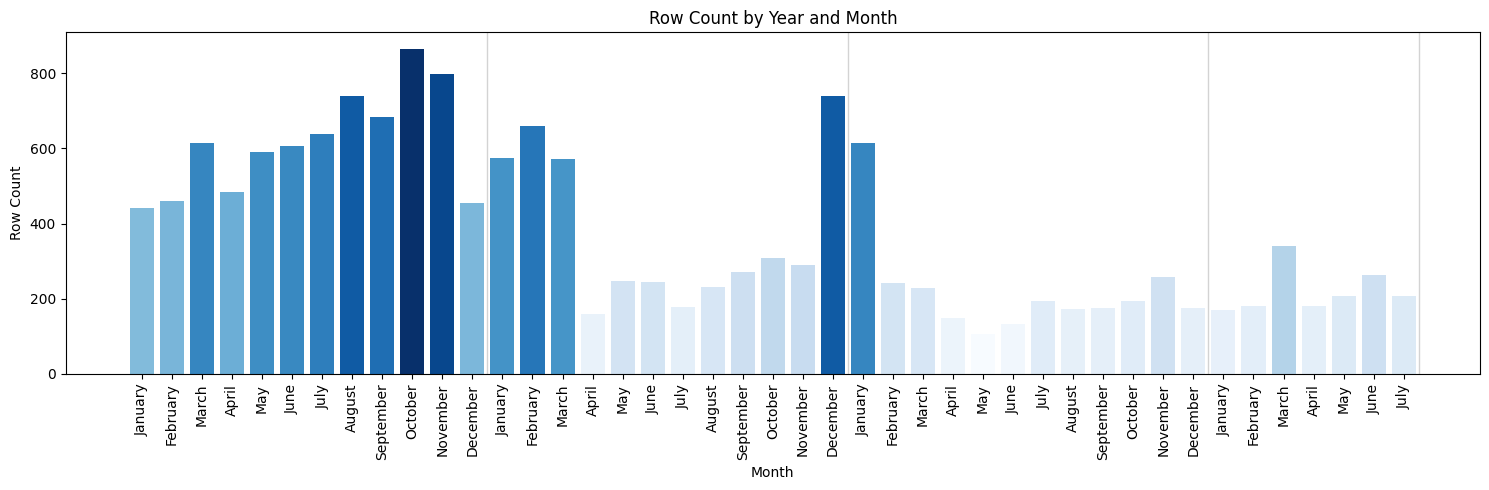

In [62]:
#AI generated
plot_df=date_stats.groupby(['year','month']).size().reset_index(name='row_count')

month_order=['January','February','March','April','May','June','July','August','September','October','November','December']

plot_df['month']=pd.Categorical(plot_df['month'],categories=month_order,ordered=True)
plot_df=plot_df.sort_values(['year','month'])
plot_df['label']=plot_df['month'].astype(str)

colors=plt.cm.Blues((plot_df['row_count']-plot_df['row_count'].min())/(plot_df['row_count'].max()-plot_df['row_count'].min()))

plt.figure(figsize=(15,5))
plt.bar(range(len(plot_df)),plot_df['row_count'],color=colors)
plt.xticks(range(len(plot_df)),plot_df['label'],rotation=90)
plt.ylabel('Row Count')
plt.xlabel('Month')
plt.title('Row Count by Year and Month')
for _,group in plot_df.groupby('year'):
    plt.axvline(group.index.max()+0.5,color='lightgray',linewidth=1)
plt.tight_layout()
plt.show()

In [63]:
print(date_stats['year'].value_counts())
print(date_stats['year'].value_counts(normalize=True).round(4)*100)

year
2019    7371
2020    4472
2021    2645
2022    1550
Name: count, dtype: int64
year
2019    45.96
2020    27.88
2021    16.49
2022     9.66
Name: proportion, dtype: float64


In [64]:
print(date_stats['month'].value_counts(),'\n')
print(date_stats['month'].value_counts(normalize=True).round(4)*100, '\n')

month
January      1799
March        1752
February     1544
December     1370
October      1367
November     1345
June         1246
July         1219
May          1149
August       1143
September    1130
April         974
Name: count, dtype: int64 

month
January      11.22
March        10.92
February      9.63
December      8.54
October       8.52
November      8.39
June          7.77
July          7.60
May           7.16
August        7.13
September     7.05
April         6.07
Name: proportion, dtype: float64 



In [65]:
df[df['category_title'] == 'Covid 19'][['complaint_month','complaint_year']].sort_values(by='complaint_year',ascending=True).reset_index(drop=True)

,complaint_month,complaint_year
0,April,2020
1,April,2020
2,April,2020
3,May,2020
4,May,2020
5,May,2020
6,May,2020
7,June,2020
8,June,2020
9,July,2020


In [66]:
df[df['category_title'] == 'Covid 19']['created_at'].count()

np.int64(11)

#### **Date Analysis Insights**
NOTE : External data about events happened in the period concerned has been obtained from external sources to look up possible connections to the highs and lows present in the data.

2019 has the highest number of complaints registered with 7371 complaints (45.96%) while 2022 being the lowest with 1550 complaints (9.66%), partly because the dataset only captures upto july 2022.

Elevated complaint levels from January 2019 to March 2020 coincided with the 2019 Lok Sabha Elections, Karnataka's political crisis and government transition, Anti CAA/NRC protests, and the emergence of COVID 19. These events likely increased civic activity, public gatherings, traffic disruptions, and citizen interaction with public authorities.

The exceptionally high complaint volumes recorded in October 2019 (865) and November 2019 (797) may also be associated with the post-government-transition period and political developments surrounding the cancellation of state-sponsored Tipu Jayanti celebrations.

The elevated complaint volume observed in December 2020 (740) coincided with the then ongoing COVID 19 restrictions, economic disruptions, and BBMP administrator-led governance. These factors may have contributed to increased civic and administrative grievances.

The decline of complaint volume in 2020 may partially be associated with citizen reluctance to engage with authorities during COVID 19 restrictions, beyond just reduced civic activity.


**______________________________________________________________________________________________________________________________________________________________________________**

#### **ward-Based Analysis**

**Assumption: Open Complaint Status**  
Complaints recorded with a status of `Open` represent complaints pending acknowledgement at the time of data extraction. In the absence of a dataset cutoff date, no inference is drawn regarding whether these complaints were deliberately delayed, subsequently addressed or remain permanently unacknowledged. Hence, they are considerd in aggregate metrics since they are ultimately a part of the system, but will not be a subject of standalone ward analysis going forward.

**On-The_job Complaint Status** : 
Similarly complaints recorded with a status of `On-The-Job` are not going to be a subject of stand alone analysis going forward as meaningful interpretation requires a time factor defining the complaint flow which is unavailable in this dataset.

**Closed Complaint Status**
Complaints with a status of `Closed` were included alongside Rejected complaints when calculating the Complaint Ignorance Rate. For this analysis, The share of complaints marked Rejected or Closed, treated in this analysis as ignored. This is a simplifying assumption, as complaints may also be closed or rejected for legitimate reasons, such as insufficient information, triviality, or infeasibility of the requested action.

In [67]:
df['complaint_status_title'].value_counts(normalize=True)*100

complaint_status_title
Open          54.838509
Resolved      30.727023
On-the-Job    10.294301
Re-opened      2.070084
Rejected       1.371742
Closed         0.698341
Name: proportion, dtype: float64

In [68]:
#ward performance metrics
ward = df.groupby(['ward_title', 'ward_id'])

ward_stats = ward.agg(complaint_count=('created_at', 'count')).reset_index()

complaint_status = df.groupby(['ward_title','ward_id','complaint_status_title']).size().unstack(fill_value=0).reset_index()
ward_stats = pd.merge(ward_stats,complaint_status, on=['ward_title','ward_id'], how='left')

comments = ward['comment_count'].sum().reset_index(name='total_comments')
ward_stats = pd.merge(ward_stats, comments, how='left', on=['ward_title','ward_id'])

ward_stats.columns = ward_stats.columns.str.replace('-', '_').str.lower()

In [69]:
ward_stats['complaint_acceptance_rate'] =\
    ward_stats[['resolved', 'on_the_job','rejected','closed','re_opened']].sum(axis=1)/\
    ward_stats['complaint_count']
ward_stats['complaint_resolution_rate'] = ward_stats['resolved']/ward_stats['complaint_count']
ward_stats['complaint_ignorance_rate'] = ward_stats[['rejected','closed']].sum(axis=1)/ward_stats['complaint_count']
ward_stats['complaint_re_opening_rate'] = ward_stats['re_opened']/ward_stats['complaint_count']
ward_stats['comments_per_complaint'] = (ward_stats['total_comments'] / ward_stats['complaint_count']).round(2)
ward_stats['effective_resolution_rate'] = ward_stats['complaint_resolution_rate'] / ward_stats['complaint_acceptance_rate']

In [70]:
ward_stats_org = ward_stats[ward_stats.columns[:10]]
ward_stats = ward_stats.drop(columns=ward_stats.columns[3:10])

In [71]:
ward_stats

,ward_title,ward_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
0,A Narayanapura,56,102,0.411765,0.313725,0.019608,0.009804,1.00,0.761905
1,Adugodi,147,16,0.437500,0.062500,0.125000,0.062500,0.81,0.142857
2,Agaram,114,86,0.488372,0.313953,0.023256,0.034884,1.12,0.642857
3,Agrahara Dasarahalli,105,15,0.333333,0.333333,0.000000,0.000000,0.87,1.000000
4,Anjanapura,196,87,0.379310,0.252874,0.011494,0.011494,0.84,0.666667
...,...,...,...,...,...,...,...,...,...
193,Vrushabhavathi Nagar,102,17,0.411765,0.411765,0.000000,0.000000,0.65,1.000000
194,Yediyur,167,48,0.395833,0.208333,0.062500,0.000000,0.94,0.526316
195,Yelahanka Satellite Town,4,51,0.588235,0.470588,0.019608,0.019608,1.27,0.800000
196,Yelchenahalli,185,72,0.416667,0.250000,0.000000,0.027778,0.94,0.600000


#### ward Performance
Builds `ward_stats` with acceptance, resolution, effective resolution, ignorance, re-opening rates and comments per complaint for each ward.
`ward_stats_org` retains the raw status counts for reference.

In [72]:
cols = ['complaint_count','complaint_acceptance_rate','complaint_resolution_rate','complaint_ignorance_rate','complaint_re_opening_rate','comments_per_complaint', 'effective_resolution_rate']

In [73]:
print(ward_stats['complaint_count'].describe())

count    198.000000
mean      81.000000
std      102.897169
min        2.000000
25%       26.000000
50%       46.500000
75%       89.750000
max      727.000000
Name: complaint_count, dtype: float64


> wards cannot be judged with metrics calculated above without their population or area data, since it is unavailable in this dataset, I'm considering wards with more than 100 registered complaints.
>
> **Reasoning**: wards with higher areas or population would naturally receive more complaints than small ones, and comparing their performances without normalizing for either of the factors mentioned earlier would be simply unfair.

In [74]:
complaints = ward_stats['complaint_count']
ward_stats[complaints>100].describe()

,ward_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
count,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000
mean,105.418605,226.488372,0.454245,0.303235,0.015341,0.023903,1.317907,0.669182
std,69.503077,140.617748,0.071028,0.063575,0.010807,0.015857,0.492417,0.098578
min,3.000000,101.000000,0.248588,0.163842,0.000000,0.004630,0.720000,0.425532
25%,53.500000,139.000000,0.408739,0.257368,0.006213,0.011331,1.035000,0.600926
50%,93.000000,177.000000,0.468085,0.301961,0.015686,0.019512,1.210000,0.666667
75%,180.000000,254.000000,0.504396,0.351142,0.020842,0.030724,1.445000,0.744186
max,199.000000,727.000000,0.586466,0.444292,0.039024,0.074830,3.750000,0.875000


In [75]:
for x in cols:
    y = ward_stats[complaints.ge(100)][x].median()
    print(f'{x}: {y}')

complaint_count: 177.0
complaint_acceptance_rate: 0.4652253488904141
complaint_resolution_rate: 0.29857075360264584
complaint_ignorance_rate: 0.016107600064819316
complaint_re_opening_rate: 0.020304620767726662
comments_per_complaint: 1.2
effective_resolution_rate: 0.6705426356589147


> Exploring to see if a cohort analysis based on complaint count creates meaningful differentiation.

In [76]:
ward_stats[complaints.lt(50)].describe()

,ward_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
count,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,105.000000
mean,95.301887,26.650943,0.406584,0.278274,0.031870,0.012376,1.105755,0.678824
std,49.560193,12.841186,0.154019,0.141239,0.046968,0.025239,0.614797,0.223171
min,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,49.500000,16.000000,0.309729,0.200000,0.000000,0.000000,0.760000,0.526316
50%,100.500000,26.500000,0.428571,0.272727,0.000000,0.000000,0.970000,0.692308
75%,135.750000,37.500000,0.500000,0.347076,0.049405,0.021406,1.392500,0.833333
max,186.000000,49.000000,0.862069,0.827586,0.277778,0.142857,4.060000,1.000000


In [77]:
ward_stats[(complaints.ge(50) & (complaints.le(100)))].describe()

,ward_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
count,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000
mean,104.632653,70.897959,0.435606,0.308335,0.026240,0.015846,1.121020,0.707626
std,62.884051,14.234999,0.091989,0.077703,0.019768,0.016910,0.335468,0.083183
min,4.000000,50.000000,0.174603,0.142857,0.000000,0.000000,0.430000,0.565217
25%,50.000000,61.000000,0.379310,0.252874,0.014085,0.000000,0.960000,0.645161
50%,94.000000,68.000000,0.424242,0.290909,0.021277,0.012987,1.060000,0.717391
75%,172.000000,82.000000,0.488372,0.348485,0.040000,0.027778,1.260000,0.774194
max,196.000000,100.000000,0.630137,0.500000,0.063492,0.058824,2.500000,0.869565


In [78]:
ward_stats[(complaints.gt(100) & (complaints.le(300)))].describe()

,ward_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,103.527778,174.916667,0.447126,0.300754,0.015714,0.023582,1.316389,0.674107
std,68.837484,53.267184,0.073094,0.061011,0.011303,0.017100,0.528692,0.088852
min,3.000000,101.000000,0.248588,0.163842,0.000000,0.004630,0.720000,0.459770
25%,53.750000,131.000000,0.402083,0.257397,0.006271,0.009780,1.022500,0.610539
50%,88.500000,172.000000,0.458660,0.302980,0.016108,0.018652,1.175000,0.677083
75%,178.000000,207.750000,0.504166,0.343142,0.021277,0.030400,1.437500,0.744186
max,198.000000,292.000000,0.586466,0.417722,0.039024,0.074830,3.750000,0.875000


In [79]:
ward_stats[complaints.gt(300)].describe()

,ward_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
mean,115.142857,491.714286,0.490858,0.315989,0.013424,0.025555,1.325714,0.643850
std,77.724789,154.386651,0.047764,0.079699,0.008193,0.007119,0.258319,0.145177
min,6.000000,324.000000,0.426877,0.219178,0.000000,0.016438,0.880000,0.425532
25%,55.000000,357.000000,0.466214,0.262718,0.009658,0.020355,1.230000,0.567242
50%,149.000000,506.000000,0.492837,0.286517,0.015432,0.026217,1.360000,0.601852
75%,171.000000,585.500000,0.504448,0.368251,0.017230,0.029707,1.430000,0.749736
max,199.000000,727.000000,0.574966,0.444292,0.024759,0.036107,1.720000,0.845614


> My earlier justification for excluding wards with fewer than 100 complaint counts was not supported by the data, which revealed only marginal metric differences for all four cohorts. Hence all wards are included in the analysis going forward.
> But still wards with fewer than 100 complaint could be susceptible to small sample bias, small sample sizes produce uneven metric values that are not comparable in fair grounds. While cohort-level analysis revealed only marginal differences, individual ward comparisons remain susceptible to statistical instability.

In [80]:
ward_stats[complaints >= 100].sort_values(by='complaint_resolution_rate', ascending=False).head(10)

,ward_title,ward_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
19,Bellanduru,150,727,0.574966,0.444292,0.024759,0.031637,1.72,0.772727
16,Basavanapura,53,158,0.544304,0.417722,0.006329,0.031646,1.37,0.767442
120,Mangamannapalya,190,133,0.586466,0.406015,0.007519,0.030075,1.71,0.692308
181,Uttarahalli,184,254,0.503937,0.397638,0.027559,0.007874,0.95,0.789062
189,Vijnana Nagar,81,177,0.525424,0.384181,0.011299,0.050847,1.81,0.731183
60,HSR Layout,174,292,0.517123,0.380137,0.027397,0.027397,1.34,0.735099
138,Other,199,637,0.447410,0.378336,0.017268,0.036107,0.88,0.845614
70,Hoodi,54,254,0.507874,0.377953,0.003937,0.059055,1.59,0.744186
42,Dodda Nekkundi,85,349,0.492837,0.358166,0.017192,0.022923,1.40,0.726744
145,Puttenahalli,187,144,0.500000,0.354167,0.034722,0.006944,2.00,0.708333


In [81]:
ward_stats.sort_values(by='complaint_resolution_rate', ascending=False).head(10)

,ward_title,ward_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
56,Gurappanpalya,171,29,0.862069,0.827586,0.000000,0.034483,1.86,0.960000
127,Mattikere,36,21,0.714286,0.714286,0.000000,0.000000,1.62,1.000000
94,Kadugondanahalli,30,5,0.600000,0.600000,0.000000,0.000000,1.60,1.000000
89,K R Market,139,32,0.781250,0.562500,0.093750,0.031250,1.66,0.720000
102,Kempegowda,1,39,0.615385,0.512821,0.000000,0.025641,1.97,0.833333
57,HAL Airport,87,66,0.590909,0.500000,0.000000,0.015152,1.32,0.846154
139,Padarayanapura,135,2,0.500000,0.500000,0.000000,0.000000,1.00,1.000000
174,Suddagunte Palya,152,44,0.590909,0.477273,0.022727,0.022727,1.41,0.807692
195,Yelahanka Satellite Town,4,51,0.588235,0.470588,0.019608,0.019608,1.27,0.800000
131,Nagarabhavi,128,30,0.533333,0.466667,0.000000,0.033333,1.73,0.875000


>Looking at the above data, Gurappanpalya with 82% resolution rate with only 29 complaints and Padarayanapura with 50% resolution rate with only 2 complaints is disproportionately higher, which confirms that wards with lower complaint volume are susceptible to small sample bias. Hence moving forward only wards with more than 100 complaints will be considered.

In [82]:
ward_stats[complaints >= 100].sort_values(by='complaint_acceptance_rate', ascending=False).head(10)

,ward_title,ward_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
120,Mangamannapalya,190,133,0.586466,0.406015,0.007519,0.030075,1.71,0.692308
19,Bellanduru,150,727,0.574966,0.444292,0.024759,0.031637,1.72,0.772727
16,Basavanapura,53,158,0.544304,0.417722,0.006329,0.031646,1.37,0.767442
93,Kadugodi,83,180,0.533333,0.333333,0.016667,0.038889,1.90,0.625000
79,Jakkuru,5,165,0.527273,0.242424,0.012121,0.006061,1.12,0.459770
189,Vijnana Nagar,81,177,0.525424,0.384181,0.011299,0.050847,1.81,0.731183
151,Ramamurthy Nagar,26,255,0.521569,0.301961,0.015686,0.031373,1.40,0.578947
60,HSR Layout,174,292,0.517123,0.380137,0.027397,0.027397,1.34,0.735099
178,Thanisandra,6,365,0.515068,0.219178,0.013699,0.016438,1.46,0.425532
70,Hoodi,54,254,0.507874,0.377953,0.003937,0.059055,1.59,0.744186


In [83]:
ward_stats[complaints >= 100].sort_values(by='effective_resolution_rate', ascending=True).head(10)

,ward_title,ward_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
178,Thanisandra,6,365,0.515068,0.219178,0.013699,0.016438,1.46,0.425532
79,Jakkuru,5,165,0.527273,0.242424,0.012121,0.006061,1.12,0.459770
108,Kottigepalya,73,103,0.504854,0.262136,0.038835,0.009709,1.17,0.519231
61,Hagadur,84,237,0.438819,0.236287,0.029536,0.021097,1.03,0.538462
183,Varthur,149,324,0.493827,0.268519,0.015432,0.027778,1.36,0.543750
58,HBR Layout,24,175,0.405714,0.234286,0.017143,0.028571,1.15,0.577465
151,Ramamurthy Nagar,26,255,0.521569,0.301961,0.015686,0.031373,1.40,0.578947
22,Bilekahalli,188,236,0.470339,0.275424,0.025424,0.012712,1.21,0.585586
18,Begur,192,534,0.485019,0.286517,0.005618,0.026217,1.27,0.590734
66,Hemmigepura,198,134,0.328358,0.194030,0.000000,0.007463,0.77,0.590909


In [84]:
ward_stats[complaints >= 100].sort_values(by='complaint_ignorance_rate', ascending=True).head(10)

,ward_title,ward_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
8,Atturu,3,115,0.400000,0.313043,0.000000,0.008696,1.12,0.782609
54,Gottigere,194,123,0.430894,0.276423,0.000000,0.048780,1.43,0.641509
71,Horamavu,25,506,0.426877,0.256917,0.000000,0.017787,1.19,0.601852
66,Hemmigepura,198,134,0.328358,0.194030,0.000000,0.007463,0.77,0.590909
106,Konena Agrahara,113,125,0.496000,0.304000,0.000000,0.024000,1.21,0.612903
104,Kodigehalli,8,101,0.415842,0.257426,0.000000,0.059406,0.98,0.619048
70,Hoodi,54,254,0.507874,0.377953,0.003937,0.059055,1.59,0.744186
18,Begur,192,534,0.485019,0.286517,0.005618,0.026217,1.27,0.590734
25,Byatarayanapura,7,173,0.369942,0.254335,0.005780,0.017341,1.04,0.687500
185,Vasanthapura,197,166,0.469880,0.295181,0.006024,0.018072,1.60,0.628205


In [85]:
ward_stats[complaints >= 100].sort_values(by='complaint_re_opening_rate', ascending=True).head(10)

,ward_title,ward_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
184,Vasanth Nagar,93,216,0.402778,0.305556,0.009259,0.004630,3.75,0.758621
79,Jakkuru,5,165,0.527273,0.242424,0.012121,0.006061,1.12,0.459770
145,Puttenahalli,187,144,0.500000,0.354167,0.034722,0.006944,2.00,0.708333
66,Hemmigepura,198,134,0.328358,0.194030,0.000000,0.007463,0.77,0.590909
181,Uttarahalli,184,254,0.503937,0.397638,0.027559,0.007874,0.95,0.789062
87,Jnana Bharathi,129,121,0.355372,0.264463,0.016529,0.008264,0.95,0.744186
8,Atturu,3,115,0.400000,0.313043,0.000000,0.008696,1.12,0.782609
150,Rajarajeshwari Nagar,160,222,0.454955,0.324324,0.018018,0.009009,0.89,0.712871
108,Kottigepalya,73,103,0.504854,0.262136,0.038835,0.009709,1.17,0.519231
0,A Narayanapura,56,102,0.411765,0.313725,0.019608,0.009804,1.00,0.761905


In [86]:
ward_stats[complaints >= 100].sort_values(by='complaint_count', ascending=False).head(10)

,ward_title,ward_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
19,Bellanduru,150,727,0.574966,0.444292,0.024759,0.031637,1.72,0.772727
138,Other,199,637,0.447410,0.378336,0.017268,0.036107,0.88,0.845614
18,Begur,192,534,0.485019,0.286517,0.005618,0.026217,1.27,0.590734
71,Horamavu,25,506,0.426877,0.256917,0.000000,0.017787,1.19,0.601852
178,Thanisandra,6,365,0.515068,0.219178,0.013699,0.016438,1.46,0.425532
42,Dodda Nekkundi,85,349,0.492837,0.358166,0.017192,0.022923,1.40,0.726744
183,Varthur,149,324,0.493827,0.268519,0.015432,0.027778,1.36,0.543750
60,HSR Layout,174,292,0.517123,0.380137,0.027397,0.027397,1.34,0.735099
169,Singasandra,191,279,0.462366,0.340502,0.014337,0.021505,1.46,0.736434
151,Ramamurthy Nagar,26,255,0.521569,0.301961,0.015686,0.031373,1.40,0.578947


In [87]:
# a helper function to pick out the ward titles by the respective sorting order
def ward_stat_picker(column_name, ascending=False, force = 10):
    if ascending:
        daf = ward_stats[ward_stats['complaint_count']>100].sort_values(by= column_name, ascending=True).head(force)
        duf = list(daf['ward_title'])    
        return duf
    else:
        daf = ward_stats[ward_stats['complaint_count']>100].sort_values(by= column_name, ascending=False).head(force)
        duf = list(daf['ward_title'])    
        return duf

In [88]:
# a helper to pick out the most common wards to figure out performance of the wards.
def top_10(positive_cols, negative_cols, mode='best'):
    if mode == 'best':
        empty = []
        for i in positive_cols:
            empty.extend(ward_stat_picker(i))
        for i in negative_cols:
            empty.extend(ward_stat_picker(i, ascending=True))
        from collections import Counter

        count = Counter(empty)
        best_10 = []
        for ward, appearances in count.most_common():
            best_10.append(f"{ward}: {appearances}")
        return best_10

    if mode == 'worst':
        empty = []
        for i in positive_cols:
            empty.extend(ward_stat_picker(i, ascending=True))
        for i in negative_cols:
            empty.extend(ward_stat_picker(i))
        from collections import Counter

        count = Counter(empty)
        worst_10 = []
        for ward, appearances in count.most_common():
            worst_10.append(f"{ward}: {appearances}")
        return worst_10

In [89]:
pos_cols = ['complaint_count', 'complaint_acceptance_rate','complaint_resolution_rate','effective_resolution_rate']
neg_cols = ['complaint_ignorance_rate','complaint_re_opening_rate','comments_per_complaint']

In [90]:
top_10(positive_cols=pos_cols, negative_cols=neg_cols, mode='best')

['Bellanduru: 4',
 'Other: 4',
 'Uttarahalli: 4',
 'HSR Layout: 3',
 'Basavanapura: 3',
 'Hoodi: 3',
 'Atturu: 3',
 'A Narayanapura: 3',
 'Hemmigepura: 3',
 'Begur: 2',
 'Horamavu: 2',
 'Thanisandra: 2',
 'Dodda Nekkundi: 2',
 'Ramamurthy Nagar: 2',
 'Mangamannapalya: 2',
 'Jakkuru: 2',
 'Vijnana Nagar: 2',
 'Puttenahalli: 2',
 'Vidyaranyapura: 2',
 'Vasanth Nagar: 2',
 'Kodigehalli: 2',
 'Jnana Bharathi: 2',
 'Rajarajeshwari Nagar: 2',
 'Varthur: 1',
 'Singasandra: 1',
 'Kadugodi: 1',
 'Shantala Nagar: 1',
 'Koramangala: 1',
 'Gottigere: 1',
 'Konena Agrahara: 1',
 'Byatarayanapura: 1',
 'Vasanthapura: 1',
 'Kottigepalya: 1',
 'Sampangiram Nagar: 1',
 'Arekere: 1']

In [91]:
top_10(positive_cols=pos_cols, negative_cols=neg_cols, mode='worst')

['Kottigepalya: 3',
 'Hemmigepura: 3',
 'Arekere: 3',
 'Hagadur: 3',
 'Bellanduru: 3',
 'Kodigehalli: 2',
 'Vidyaranyapura: 2',
 'New Tippasandra: 2',
 'Atturu: 2',
 'Jnana Bharathi: 2',
 'Gottigere: 2',
 'Mangamannapalya: 2',
 'Sampangiram Nagar: 2',
 'Hoysala Nagar: 2',
 'Byatarayanapura: 2',
 'Banasavadi: 2',
 'Vasanth Nagar: 2',
 'Thanisandra: 2',
 'HBR Layout: 2',
 'Jakkuru: 2',
 'Bilekahalli: 2',
 'Puttenahalli: 2',
 'Hoodi: 2',
 'Vijnana Nagar: 2',
 'Kadugodi: 2',
 'A Narayanapura: 1',
 'Konena Agrahara: 1',
 'Horamavu: 1',
 'Varthur: 1',
 'Ramamurthy Nagar: 1',
 'Begur: 1',
 'BTM Layout: 1',
 'Uttarahalli: 1',
 'HSR Layout: 1',
 'C V Raman Nagar: 1',
 'Other: 1',
 'Basavanapura: 1',
 'Shantala Nagar: 1',
 'Vasanthapura: 1',
 'Singasandra: 1']

In [92]:
df[df['ward_title'] == 'C V Raman Nagar']

,created_at,ward_id,title,description,sub_category_id,civic_agency_id,location,address,latitude,longitude,ward_title,category_id,category_title,sub_category_title,civic_agency_title,complaint_status_title,comment_count,complaint_month,complaint_year
18,2019-01-02 17:03:00,57,Garbage not removed from road,Garbage not removed from road,155,10.0,"26 B Cross, C.v. Raman Nagar, Kaggadasapura, B...",Not Provided,12.981735,77.679166,C V Raman Nagar,6.0,Garbage and Unsanitary Practices,Clearance Of Garbage Dump Or Black Spot,BBMP,Resolved,5,January,2019
237,2019-01-16 14:48:00,57,Garbage collection auto's are not coming to 10...,"Hi, \n\nGarbage collecting persons are not com...",442,10.0,"10Th Nagavarapalya I-Cross Rd, Nagavarapalya, ...",Suryodaya enclave apartments,12.991211,77.665544,C V Raman Nagar,6.0,Garbage and Unsanitary Practices,Collection Of Door-to-door Garbage,BBMP,Resolved,2,January,2019
298,2019-01-21 17:28:00,57,Garbage piled up on footpath every day,There is garbage piled up on the footpath of N...,155,10.0,"Nagavarapalya, C V Raman Nagar, Bengaluru, Kar...",Near Mediplus,12.989012,77.666498,C V Raman Nagar,6.0,Garbage and Unsanitary Practices,Clearance Of Garbage Dump Or Black Spot,BBMP,Resolved,2,January,2019
570,2019-02-09 12:50:00,57,Left over food,Some residents have been throwing left over fo...,444,10.0,"49, 9Th Cross Rd, Maruthi Nagar, Malleshpalya,...",9th Cross board,12.975502,77.676487,C V Raman Nagar,6.0,Garbage and Unsanitary Practices,Garbage Dumping In Vacant Lot/Land,BBMP,Resolved,2,February,2019
612,2019-02-11 21:36:00,57,Restoring Kagadassapura lake,The Kagadassapura lake has been completely cov...,155,10.0,"Kaggadasapura Lake, Bengaluru, Karnataka",C V Ramanagar,12.981411,77.670077,C V Raman Nagar,6.0,Garbage and Unsanitary Practices,Clearance Of Garbage Dump Or Black Spot,BBMP,Resolved,2,February,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15618,2022-06-07 15:42:00,57,Pathetic condition of the underpass in old mad...,Pathetic condition of the underpass in old mad...,56,10.0,"Icici Bank Old Madras Road, Bangalore-Branch &...",Not Provided,12.994107,77.663862,C V Raman Nagar,15.0,"Mobility - Roads, Footpaths and Infrastructure",Flooding/Waterlogging Of Roads And Footpaths,BBMP,Open,0,June,2022
15727,2022-06-21 10:47:00,57,Stray bits children,"HI,\n\nin malleshpalya 10th main road, 1st cro...",77,10.0,"6, 1St Cross Rd, Malleshpalya, Kaggadasapura, ...",Near bharma super market,12.974132,77.674677,C V Raman Nagar,19.0,Animal Husbandry,Stray Dog Sterilisation/Animal Birth Control (...,BBMP,Open,0,June,2022
15728,2022-06-21 11:31:00,57,Dangerous Dogs bits children,"HI,\nin malleshpalya 10th main road, 1st cross...",77,10.0,"6, 1St Cross Rd, Malleshpalya, Kaggadasapura, ...",Near bharma super market,12.974148,77.674682,C V Raman Nagar,19.0,Animal Husbandry,Stray Dog Sterilisation/Animal Birth Control (...,BBMP,Open,0,June,2022
15828,2022-06-30 14:05:00,57,Drainage flooding school road,Everyday morning drainage flooding school road...,344,10.0,"Near Apollo Pharmacy, 11, 8Th Cross Road, Maru...",Sri chaitanya school grade 1 &2 building,12.977093,77.676640,C V Raman Nagar,15.0,"Mobility - Roads, Footpaths and Infrastructure",Desilting Existing Roadside Drains,BBMP,Open,0,June,2022


In [93]:
ward_stats[complaints >= 100].sort_values(by='comments_per_complaint', ascending=True).head(10)

,ward_title,ward_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
156,Sampangiram Nagar,110,177,0.248588,0.163842,0.016949,0.016949,0.72,0.659091
66,Hemmigepura,198,134,0.328358,0.194030,0.000000,0.007463,0.77,0.590909
187,Vidyaranyapura,9,104,0.307692,0.269231,0.009615,0.019231,0.78,0.875000
138,Other,199,637,0.447410,0.378336,0.017268,0.036107,0.88,0.845614
150,Rajarajeshwari Nagar,160,222,0.454955,0.324324,0.018018,0.009009,0.89,0.712871
6,Arekere,193,188,0.398936,0.255319,0.021277,0.015957,0.91,0.640000
181,Uttarahalli,184,254,0.503937,0.397638,0.027559,0.007874,0.95,0.789062
87,Jnana Bharathi,129,121,0.355372,0.264463,0.016529,0.008264,0.95,0.744186
104,Kodigehalli,8,101,0.415842,0.257426,0.000000,0.059406,0.98,0.619048
0,A Narayanapura,56,102,0.411765,0.313725,0.019608,0.009804,1.00,0.761905


In [94]:
print(ward_stats[complaints >= 100]['comments_per_complaint'].skew())
print(ward_stats[complaints >= 100]['comments_per_complaint'].median())

3.029527404375248
1.2


In [95]:
print(ward_stats[(complaints >= 100) & (ward_stats['comments_per_complaint'] >= 1.2)][cols].mean())
print('-------------------------------------------------')
print(ward_stats[(complaints >= 100) & (ward_stats['comments_per_complaint'] < 1.2)][cols].mean())

complaint_count              252.500000
complaint_acceptance_rate      0.495338
complaint_resolution_rate      0.331209
complaint_ignorance_rate       0.015906
complaint_re_opening_rate      0.026284
comments_per_complaint         1.611364
effective_resolution_rate      0.668321
dtype: float64
-------------------------------------------------
complaint_count              194.727273
complaint_acceptance_rate      0.412051
complaint_resolution_rate      0.274658
complaint_ignorance_rate       0.015442
complaint_re_opening_rate      0.021800
comments_per_complaint         1.014091
effective_resolution_rate      0.670280
dtype: float64


> Exploring to see if complaints created in certain periods are more likely to get re-opened.

In [96]:
df['is_reopened'] = (df['complaint_status_title'] == 'Re-opened').astype(int)

In [97]:
df[df['is_reopened'] == 1][['complaint_month','complaint_year']].value_counts(normalize=True)

complaint_month  complaint_year
February         2019              0.126506
March            2019              0.114458
June             2019              0.102410
January          2019              0.078313
May              2019              0.075301
April            2019              0.060241
January          2020              0.060241
October          2019              0.057229
August           2019              0.054217
November         2019              0.048193
September        2019              0.042169
July             2019              0.030120
December         2019              0.024096
February         2020              0.021084
March            2020              0.018072
September        2021              0.012048
February         2021              0.012048
August           2020              0.009036
February         2022              0.006024
May              2022              0.006024
July             2020              0.006024
January          2021              0.006024


In [98]:
df[(df['is_reopened'] == 1) & (df['ward_title'] == 'C V Raman Nagar')][['complaint_month','complaint_year']].value_counts(normalize=True)

complaint_month  complaint_year
June             2019              0.818182
August           2019              0.090909
May              2019              0.090909
Name: proportion, dtype: float64

> February, March and June of 2019 have the most of complaints re-opened, but nothing could be found to explain the spike.
> The spike in re-opened complaints in june 2019 in `Sir C V Raman Nagar` could be likely due to the world environmental day awareness program hosted there.

> Exploring to see if any ward has complaints concentrated in any particular agency.

In [99]:
ge_100 = list(ward_stats[ward_stats['complaint_count'].ge(100)]['ward_title'])


ward_agency_dist = df[df['ward_title'].isin(ge_100)]\
    .groupby('ward_title')['civic_agency_title'].value_counts(normalize=True).unstack(fill_value=0)\
    .map(lambda x: round((x*100), 2))


ward_agency_dist.skew()

civic_agency_title
BBMP           -1.747414
BCP             0.927031
BDA             4.609664
BESCOM          2.019517
BMTC            2.174971
BTC             3.171107
BWSSB           1.638965
KSFES           3.142018
KSPCB           1.184224
KSRTC           5.187165
Not Assigned    1.581323
dtype: float64

In [100]:
ward_agency_dist.median()

civic_agency_title
BBMP            84.035
BCP              0.620
BDA              0.000
BESCOM           0.995
BMTC             0.000
BTC              4.830
BWSSB            4.435
KSFES            0.000
KSPCB            2.505
KSRTC            0.000
Not Assigned     1.720
dtype: float64

In [101]:
ward_agency_dist

civic_agency_title,BBMP,BCP,BDA,BESCOM,BMTC,BTC,BWSSB,KSFES,KSPCB,KSRTC,Not Assigned
ward_title,,,,,,,,,,,
A Narayanapura,83.33,0.00,0.00,0.98,0.00,4.90,4.90,0.00,4.90,0.00,0.98
Arekere,84.04,0.00,0.00,2.66,0.00,3.19,4.79,0.00,2.13,0.00,3.19
Atturu,79.13,2.61,0.00,0.00,1.74,1.74,8.70,0.00,5.22,0.00,0.87
BTM Layout,69.76,1.46,0.00,6.34,0.00,10.73,7.80,0.00,2.93,0.00,0.98
Banasavadi,88.30,1.75,0.00,0.58,0.00,2.34,3.51,0.00,0.58,0.00,2.92
Basavanapura,83.54,1.27,0.00,1.90,0.00,0.63,4.43,0.00,8.23,0.00,0.00
Begur,86.52,1.12,0.00,1.69,0.37,0.94,5.43,0.19,2.25,0.00,1.50
Bellanduru,83.22,0.14,0.00,0.69,0.14,9.35,2.34,0.00,2.61,0.00,1.51
Bilekahalli,90.68,0.42,0.00,1.27,0.00,3.81,2.12,0.00,1.27,0.00,0.42


> Exploring to see the wards and their peak complaint periods.

In [102]:
ward_period_dist = df[df['ward_title'].isin(ge_100)]\
    .groupby(['complaint_year','complaint_month'])['ward_title']\
    .value_counts().rename('complaint_count').reset_index()


ward_period_dist['total'] = ward_period_dist.groupby('ward_title')['complaint_count'].transform('sum')
ward_period_dist['complaint/period'] = ward_period_dist['complaint_count'] / ward_period_dist['total']

max_vals = ward_period_dist.groupby('ward_title')['complaint/period'].transform('max')

max_comp_per_ward = ward_period_dist[ward_period_dist['complaint/period'] == max_vals]

In [103]:
max_comp_per_ward['complaint/period'].quantile(0.9)

np.float64(0.12994350282485875)

In [104]:
max_comp_per_ward[max_comp_per_ward['complaint/period'].ge(0.1299)].sort_values(by='complaint/period', ascending=False)

,complaint_year,complaint_month,ward_title,complaint_count,total,complaint/period
427,2019,October,Vasanth Nagar,54,216,0.250000
583,2020,December,Hoysala Nagar,37,164,0.225610
787,2020,March,Kodigehalli,19,101,0.188119
252,2019,June,C V Raman Nagar,24,147,0.163265
584,2020,December,Bilekahalli,35,236,0.148305
586,2020,December,Sampangiram Nagar,23,177,0.129944


In [105]:
ward_stats.to_csv(r'data/ward_stats.csv')

#### **ward-Based Analysis Insights**
`Bellanduru` with the highest complaint resolution rate (44.42%), second highest complaint acceptance rate(57.5%) and the most no. of complaints received (727) has displayed elite efficiency in grievance redressal and civic engagement.

`Hagadur` has an acceptance of 43.88% and yet has an ignorance rate of 2.95% which is two times the median value, and also below average in other metrics (resolution rate: 23.63% and effective resolution: 53.85%) indicates a consistent and clear underperformance.

`Atturu, Gottigere, Horamavu, Hemmigepura, Agrahara, Kodigehalli` have zero ignorance rate despite receiving more than 100 complaints on average and specifically `Horamavu` has exhibited an excellent complain handling process with 506 complaints received.

`Sampangiram Nagar` with the lowest acceptance rate (24.86%) and resolution rate (16.38) has yet to acknowledge most of its complaints.

`Sir C V Raman Nagar` leads in complaint re opeining rate with 7.48% compared to the average of 2.4%.

As Bengaluru's primary municipal body, BBMP's ward-level dominance is expected, accounting for over 70% of all complaints in every relevant ward except two. No other agency exceeds this threshold in any ward

Complaint categories with more than 1.2 comments per complaint exhibit higher acceptance (49.53% versus 41.21%) and resolution rates (33.12% versus 27.47%). However, similar effective resolution rates (~67% )among acknowledged complaints suggest that comment activity may be associated with complaint engagement rather than directly influencing final resolution outcomes.

Ward-level concentration by category was also considered, but since Mobility - Roads, Footpaths and Infrastructure dominates complaint volume city-wide, this would likely just reflect the category's overall dominance rather than any ward-specific pattern, similar to the redundancy noted for agency-level concentration. Not pursued further
**______________________________________________________________________________________________________________________________________________________________________________________**

out of six wards that showed unusual high complaint concentration (>13%, 90th percentile) within a single month:

- `Bilekahalli, Sampangiram Nagar and Hoysala Nagar` (concentrated in Dec 2020) consistent with the spike in citywide complaint levels likely due to covid restrictions and BBMP administrator-led governance
- `Vasanth Nagar` with higher complaints in Oct 2019 also coincided with post-government transition period explained above (see Date Analysis Insights).
- `Kodegahalli` with their complaints clustered in March 2020 could be linked to the broader period of political instability and civic disruption, which are explained above (see Date Analysis Insights).
- `Sir C V Raman Nagar` held a city wide World Environment day in June 2019 event which could be responsible for the higher concentration and higher re-open rate.

**______________________________________________________________________________________________________________________________________________________________________________**

#### **Agency-Based Analysis**

**Note:** Same status assumptions from the ward Analysis section apply here.

In [106]:
# Agency Performance Metrics

agency = df.groupby(['civic_agency_title', 'civic_agency_id'])

agency_stats = agency.agg(complaint_count=('created_at', 'count')).reset_index()

complaint_status_agency = df.groupby(['civic_agency_title', 'civic_agency_id', 'complaint_status_title']).size()\
    .unstack(fill_value=0).reset_index()
agency_stats = pd.merge(agency_stats, complaint_status_agency, on=['civic_agency_title', 'civic_agency_id'], how='left')

comments = agency['comment_count'].sum().reset_index(name='total_comments')
agency_stats = pd.merge(agency_stats, comments, how='left', on=['civic_agency_title','civic_agency_id'])

agency_stats.columns = agency_stats.columns.str.replace('-', '_').str.lower()

In [107]:
agency_stats['complaint_acceptance_rate'] = \
    agency_stats[['resolved', 'on_the_job', 'rejected', 'closed', 're_opened']].sum(axis=1)/\
    agency_stats['complaint_count'] 
agency_stats['complaint_resolution_rate'] = agency_stats['resolved'] / agency_stats['complaint_count'] 
agency_stats['complaint_ignorance_rate'] = agency_stats[['rejected', 'closed']].sum(axis=1) / agency_stats['complaint_count'] 
agency_stats['complaint_re_opening_rate'] = agency_stats['re_opened'] / agency_stats['complaint_count'] 
agency_stats['comments_per_complaint'] = (agency_stats['total_comments'] / agency_stats['complaint_count'])
agency_stats['effective_resolution_rate'] = agency_stats['complaint_resolution_rate'] / agency_stats['complaint_acceptance_rate']

In [108]:
agency_stats_org = agency_stats[agency_stats.columns[:10]]
agency_stats = agency_stats.drop(columns=agency_stats.columns[3:10])
agency_stats = agency_stats.rename(columns={'civic_agency_id' : 'agency_id', 'civic_agency_title' : 'agency_title'})

#### Agency Performance
Builds `agency_stats` with acceptance, resolution, effective resolution, ignorance, re-opening rates and comments per complaint for each agency.
`agency_stats_org` retains the raw status counts for reference.

In [109]:
agency_stats_org

,civic_agency_title,civic_agency_id,complaint_count,closed,on_the_job,open,re_opened,rejected,resolved,total_comments
0,BBMP,10.0,13112,0,1647,6503,316,3,4643,19046
1,BCP,4.0,154,0,0,147,0,0,7,35
2,BDA,6.0,4,0,0,4,0,0,0,0
3,BESCOM,1.0,241,0,0,228,0,0,13,56
4,BMTC,8.0,37,0,0,37,0,0,0,8
5,BTC,5.0,986,112,0,459,8,217,190,626
6,BWSSB,2.0,680,0,2,629,5,0,44,211
7,KSFES,11.0,10,0,0,10,0,0,0,2
8,KSPCB,7.0,437,0,2,421,3,0,11,106
9,KSRTC,15.0,4,0,0,4,0,0,0,0


In [110]:
agency_stats.sort_values(by='complaint_resolution_rate', ascending=False)

,agency_title,agency_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
0,BBMP,10.0,13112,0.504042,0.354103,0.000229,0.024100,1.452563,0.702527
5,BTC,5.0,986,0.534483,0.192698,0.333671,0.008114,0.634888,0.360531
6,BWSSB,2.0,680,0.075000,0.064706,0.000000,0.007353,0.310294,0.862745
3,BESCOM,1.0,241,0.053942,0.053942,0.000000,0.000000,0.232365,1.000000
10,Not Assigned,-1.0,373,0.053619,0.053619,0.000000,0.000000,0.230563,1.000000
1,BCP,4.0,154,0.045455,0.045455,0.000000,0.000000,0.227273,1.000000
8,KSPCB,7.0,437,0.036613,0.025172,0.000000,0.006865,0.242563,0.687500
2,BDA,6.0,4,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
4,BMTC,8.0,37,0.000000,0.000000,0.000000,0.000000,0.216216,NaN
7,KSFES,11.0,10,0.000000,0.000000,0.000000,0.000000,0.200000,NaN


> Only agencies with more than 100 complaint counts will be considered moving forward, since agencies with lower complaint volumes carry small sample bias which can elevate values disproportionately as demonstrated in ward analysis.

In [111]:
cols = ['complaint_count','complaint_acceptance_rate','complaint_resolution_rate','complaint_ignorance_rate','complaint_re_opening_rate','comments_per_complaint']
agency = agency_stats['complaint_count']
for x in cols:
    y = agency_stats[agency.ge(100)][x].mean()
    print(f'{x}: {y}')

complaint_count: 2283.285714285714
complaint_acceptance_rate: 0.1861648409842799
complaint_resolution_rate: 0.11281344922861783
complaint_ignorance_rate: 0.04770002823455864
complaint_re_opening_rate: 0.006633083001618195
comments_per_complaint: 0.47578698545109066


In [112]:
ge100_agency = agency_stats[agency_stats['complaint_count'].ge(100)]['agency_title']

agency_period_dist = df[df['civic_agency_title'].isin(ge100_agency)]\
    .groupby(['complaint_year','complaint_month'])['civic_agency_title']\
    .value_counts().rename('complaint_count').reset_index()


agency_period_dist['total'] = agency_period_dist.groupby('civic_agency_title')['complaint_count'].transform('sum')
agency_period_dist['complaint/period'] = agency_period_dist['complaint_count'] / agency_period_dist['total']

max_vals = agency_period_dist.groupby('civic_agency_title')['complaint/period'].transform('max')

max_comp_per_agency = agency_period_dist[agency_period_dist['complaint/period'] == max_vals]

max_comp_per_agency

,complaint_year,complaint_month,civic_agency_title,complaint_count,total,complaint/period
8,2019,August,BTC,63,986,0.063895
50,2019,March,BWSSB,53,680,0.077941
53,2019,March,BCP,10,154,0.064935
57,2019,May,BESCOM,26,241,0.107884
70,2019,October,BBMP,776,13112,0.059182
80,2019,September,Not Assigned,23,373,0.061662
113,2020,January,KSPCB,26,437,0.059497


In [113]:
agency_stats[agency.ge(100)].sort_values(by='complaint_resolution_rate', ascending=False)

,agency_title,agency_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
0,BBMP,10.0,13112,0.504042,0.354103,0.000229,0.024100,1.452563,0.702527
5,BTC,5.0,986,0.534483,0.192698,0.333671,0.008114,0.634888,0.360531
6,BWSSB,2.0,680,0.075000,0.064706,0.000000,0.007353,0.310294,0.862745
3,BESCOM,1.0,241,0.053942,0.053942,0.000000,0.000000,0.232365,1.000000
10,Not Assigned,-1.0,373,0.053619,0.053619,0.000000,0.000000,0.230563,1.000000
1,BCP,4.0,154,0.045455,0.045455,0.000000,0.000000,0.227273,1.000000
8,KSPCB,7.0,437,0.036613,0.025172,0.000000,0.006865,0.242563,0.687500


In [114]:
df.groupby('civic_agency_title')['category_title'].value_counts()

civic_agency_title  category_title                                           
BBMP                Mobility - Roads, Footpaths and Infrastructure               5183
                    Garbage and Unsanitary Practices                             3933
                    Street lighting                                              1498
                    Yellow Spot                                                   961
                    Animal Husbandry                                              859
                    Community Infrastructure and Services                         133
                    Storm Water Drains                                            129
                    Parks & Recreation                                            121
                    Trees and Saplings                                            104
                    Public Toilets                                                 61
                    Lakes                                     

#### **Agency-Based Analysis Insights**
Among agencies receiving more than 100 complaints, only `BBMP` and `BTC` demonstrated statistically comparable performance, as more than ~85% of complaints assigned to the remaining agencies remained unacknowledged. `BBMP` recorded an acceptance rate of 50.40%, a resolution rate of 35.41% and an effective resolution rate of 70.25%, while `BTC` recorded a resolution rate of 19.27%, an effective resolution rate of 36% and a higher ignorance rate of 3.34%.

`BBMP's` dominance is expected. As the primary municipal body, it covers the broadest range of complaint categories and receives the highest complaint volume, yet maintained a 70% effective resolution rate despite operating at a significantly larger scale than any other agency in the dataset. In contrast, `BTC` has an effective resolution rate of 36% and ignorance rate of 33%, on further analysis of categories and sub categories, it is revealed that `BTC` has only one category under it and `BTC's` lower resolution, effective resolution and higher ignorance rates are driven by parking related sub category whose intrinsic nature provides a plausible explaination for its lower resolution and higher ignorance rates, which is detailed below.

**_____________________________________________________________________________________________________________________________________________________________________________________________________________**

#### **Category-Based Analysis**

**Note:** Same status assumptions from the category Analysis section apply here.

In [115]:
# Category performance metrics
category = df.groupby(['category_title', 'category_id'])

category_stats = category.agg(complaint_count=('created_at', 'count')).reset_index()

complaint_status = df.groupby(['category_title','category_id','complaint_status_title']).size().unstack(fill_value=0).reset_index()
category_stats = pd.merge(category_stats, complaint_status, on=['category_title','category_id'], how='left')

comments = category['comment_count'].sum().reset_index(name='total_comments')
category_stats = pd.merge(category_stats, comments, how='left', on=['category_title','category_id'])

category_stats.columns = category_stats.columns.str.replace('-', '_').str.lower()

In [116]:
category_stats['complaint_acceptance_rate'] =\
    category_stats[['resolved', 'on_the_job','rejected','closed','re_opened']].sum(axis=1)/\
    category_stats['complaint_count']
category_stats['complaint_resolution_rate'] = category_stats['resolved']/category_stats['complaint_count']
category_stats['complaint_ignorance_rate'] = category_stats[['rejected','closed']].sum(axis=1)/category_stats['complaint_count']
category_stats['complaint_re_opening_rate'] = category_stats['re_opened']/category_stats['complaint_count']
category_stats['comments_per_complaint'] = (category_stats['total_comments'] / category_stats['complaint_count']).round(2)
category_stats['effective_resolution_rate'] = category_stats['complaint_resolution_rate'] / category_stats['complaint_acceptance_rate']

In [117]:
category_stats_org = category_stats[category_stats.columns[:10]]
category_stats = category_stats.drop(columns=category_stats.columns[3:10])

In [118]:
cols = ['complaint_count','complaint_acceptance_rate','complaint_resolution_rate','complaint_ignorance_rate','complaint_re_opening_rate','comments_per_complaint']
category = category_stats['complaint_count']

for x in cols:
    y = category_stats[category.ge(100)][x].mean()
    print(f'{x}: {y}')

complaint_count: 980.4375
complaint_acceptance_rate: 0.26349094409414536
complaint_resolution_rate: 0.17613853362910623
complaint_ignorance_rate: 0.020936858077293542
complaint_re_opening_rate: 0.011894038005386964
comments_per_complaint: 0.74875


#### Category Metrics
Builds `category_stats` with acceptance, resolution, effective resolution, ignorance, re-opening rates and comments per complaint for each agency.
`category_stats_org` retains the raw status counts for reference.

In [119]:
category_stats

,category_title,category_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
0,Animal Catcher,555.0,1,0.000000,0.000000,0.000000,0.000000,0.00,NaN
1,Animal Husbandry,19.0,859,0.385332,0.318976,0.000000,0.025611,1.49,0.827795
2,Certificates,1.0,53,0.603774,0.471698,0.000000,0.000000,1.28,0.781250
3,Community Infrastructure and Services,382.0,133,0.263158,0.105263,0.000000,0.000000,0.77,0.400000
4,Covid 19,543.0,11,0.272727,0.272727,0.000000,0.000000,0.36,1.000000
5,Crime and Safety,2.0,143,0.048951,0.048951,0.000000,0.000000,0.24,1.000000
6,EMP Grievance Redressal,497.0,1,0.000000,0.000000,0.000000,0.000000,0.00,NaN
7,Electricity & Power,207.0,8,0.125000,0.125000,0.000000,0.000000,0.12,1.000000
8,Electricity and Power Supply,4.0,228,0.048246,0.048246,0.000000,0.000000,0.24,1.000000
9,Fire Pollution,562.0,1,0.000000,0.000000,0.000000,0.000000,1.00,NaN


> Only categories with more than 100 complaint counts will be considered moving forward, since categories with lower complaint volumes carry small sample bias which can elevate values disproportionately as demonstrated earlier in ward analysis.

In [120]:
category_stats[category.ge(100)].sort_values(by='complaint_acceptance_rate', ascending=False)

,category_title,category_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
11,Garbage and Unsanitary Practices,6.0,3933,0.590643,0.498347,0.000254,0.027714,1.84,0.843737
13,"Mobility - Roads, Footpaths and Infrastructure",15.0,5183,0.558750,0.304650,0.000386,0.024889,1.45,0.545235
34,Street lighting,470.0,1498,0.542056,0.445260,0.000000,0.032710,1.58,0.821429
35,Traffic and Road Safety,21.0,984,0.535569,0.193089,0.334350,0.008130,0.64,0.360531
36,Trees and Saplings,473.0,104,0.403846,0.307692,0.000000,0.019231,1.07,0.761905
1,Animal Husbandry,19.0,859,0.385332,0.318976,0.000000,0.025611,1.49,0.827795
33,Storm Water Drains,18.0,138,0.384058,0.253623,0.000000,0.014493,0.94,0.660377
3,Community Infrastructure and Services,382.0,133,0.263158,0.105263,0.000000,0.000000,0.77,0.400000
18,Parks & Recreation,22.0,121,0.198347,0.066116,0.000000,0.016529,0.53,0.333333
31,Sewerage Systems,472.0,301,0.106312,0.093023,0.000000,0.009967,0.35,0.875000


Six of sixteen categories yellow spot, pollution, water supply and services, electricity and power supply, crime and safety, sewerage systems and others have recorded a complaint acceptance rate of less than 5%, meaning 95% of their complaints remain unacknowledged, Sewage systems category showed a marginally higher acceptance rate but still only around 10%. This mirrors a similar pattern observed at the agency level, whether these complaints were accepted, or otherwise cannot be determined with the available data.

In [121]:
category_stats[category.ge(100)].sort_values(by='complaint_resolution_rate', ascending=False)

,category_title,category_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
11,Garbage and Unsanitary Practices,6.0,3933,0.590643,0.498347,0.000254,0.027714,1.84,0.843737
34,Street lighting,470.0,1498,0.542056,0.445260,0.000000,0.032710,1.58,0.821429
1,Animal Husbandry,19.0,859,0.385332,0.318976,0.000000,0.025611,1.49,0.827795
36,Trees and Saplings,473.0,104,0.403846,0.307692,0.000000,0.019231,1.07,0.761905
13,"Mobility - Roads, Footpaths and Infrastructure",15.0,5183,0.558750,0.304650,0.000386,0.024889,1.45,0.545235
33,Storm Water Drains,18.0,138,0.384058,0.253623,0.000000,0.014493,0.94,0.660377
35,Traffic and Road Safety,21.0,984,0.535569,0.193089,0.334350,0.008130,0.64,0.360531
3,Community Infrastructure and Services,382.0,133,0.263158,0.105263,0.000000,0.000000,0.77,0.400000
31,Sewerage Systems,472.0,301,0.106312,0.093023,0.000000,0.009967,0.35,0.875000
18,Parks & Recreation,22.0,121,0.198347,0.066116,0.000000,0.016529,0.53,0.333333


In [122]:
category_stats[category.ge(100)].sort_values(by='complaint_count', ascending=False)

,category_title,category_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
13,"Mobility - Roads, Footpaths and Infrastructure",15.0,5183,0.558750,0.304650,0.000386,0.024889,1.45,0.545235
11,Garbage and Unsanitary Practices,6.0,3933,0.590643,0.498347,0.000254,0.027714,1.84,0.843737
34,Street lighting,470.0,1498,0.542056,0.445260,0.000000,0.032710,1.58,0.821429
35,Traffic and Road Safety,21.0,984,0.535569,0.193089,0.334350,0.008130,0.64,0.360531
41,Yellow Spot,708.0,961,0.027055,0.026015,0.000000,0.001041,0.10,0.961538
1,Animal Husbandry,19.0,859,0.385332,0.318976,0.000000,0.025611,1.49,0.827795
21,Pollution,11.0,437,0.036613,0.025172,0.000000,0.006865,0.24,0.687500
15,Others,9.0,344,0.049419,0.049419,0.000000,0.000000,0.24,1.000000
40,Water Supply and Services,23.0,320,0.037500,0.034375,0.000000,0.003125,0.26,0.916667
31,Sewerage Systems,472.0,301,0.106312,0.093023,0.000000,0.009967,0.35,0.875000


In [123]:
category_stats[category.ge(100)].sort_values(by='effective_resolution_rate', ascending=True)

,category_title,category_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
18,Parks & Recreation,22.0,121,0.198347,0.066116,0.000000,0.016529,0.53,0.333333
35,Traffic and Road Safety,21.0,984,0.535569,0.193089,0.334350,0.008130,0.64,0.360531
3,Community Infrastructure and Services,382.0,133,0.263158,0.105263,0.000000,0.000000,0.77,0.400000
13,"Mobility - Roads, Footpaths and Infrastructure",15.0,5183,0.558750,0.304650,0.000386,0.024889,1.45,0.545235
33,Storm Water Drains,18.0,138,0.384058,0.253623,0.000000,0.014493,0.94,0.660377
21,Pollution,11.0,437,0.036613,0.025172,0.000000,0.006865,0.24,0.687500
36,Trees and Saplings,473.0,104,0.403846,0.307692,0.000000,0.019231,1.07,0.761905
34,Street lighting,470.0,1498,0.542056,0.445260,0.000000,0.032710,1.58,0.821429
1,Animal Husbandry,19.0,859,0.385332,0.318976,0.000000,0.025611,1.49,0.827795
11,Garbage and Unsanitary Practices,6.0,3933,0.590643,0.498347,0.000254,0.027714,1.84,0.843737


In [124]:
category_stats[category.ge(100)].sort_values(by='complaint_ignorance_rate', ascending=False)

,category_title,category_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
35,Traffic and Road Safety,21.0,984,0.535569,0.193089,0.334350,0.008130,0.64,0.360531
13,"Mobility - Roads, Footpaths and Infrastructure",15.0,5183,0.558750,0.304650,0.000386,0.024889,1.45,0.545235
11,Garbage and Unsanitary Practices,6.0,3933,0.590643,0.498347,0.000254,0.027714,1.84,0.843737
1,Animal Husbandry,19.0,859,0.385332,0.318976,0.000000,0.025611,1.49,0.827795
8,Electricity and Power Supply,4.0,228,0.048246,0.048246,0.000000,0.000000,0.24,1.000000
5,Crime and Safety,2.0,143,0.048951,0.048951,0.000000,0.000000,0.24,1.000000
15,Others,9.0,344,0.049419,0.049419,0.000000,0.000000,0.24,1.000000
3,Community Infrastructure and Services,382.0,133,0.263158,0.105263,0.000000,0.000000,0.77,0.400000
18,Parks & Recreation,22.0,121,0.198347,0.066116,0.000000,0.016529,0.53,0.333333
21,Pollution,11.0,437,0.036613,0.025172,0.000000,0.006865,0.24,0.687500


In [125]:
category_stats[category.ge(100)].sort_values(by='comments_per_complaint', ascending=True)

,category_title,category_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
41,Yellow Spot,708.0,961,0.027055,0.026015,0.000000,0.001041,0.10,0.961538
8,Electricity and Power Supply,4.0,228,0.048246,0.048246,0.000000,0.000000,0.24,1.000000
15,Others,9.0,344,0.049419,0.049419,0.000000,0.000000,0.24,1.000000
5,Crime and Safety,2.0,143,0.048951,0.048951,0.000000,0.000000,0.24,1.000000
21,Pollution,11.0,437,0.036613,0.025172,0.000000,0.006865,0.24,0.687500
40,Water Supply and Services,23.0,320,0.037500,0.034375,0.000000,0.003125,0.26,0.916667
31,Sewerage Systems,472.0,301,0.106312,0.093023,0.000000,0.009967,0.35,0.875000
18,Parks & Recreation,22.0,121,0.198347,0.066116,0.000000,0.016529,0.53,0.333333
35,Traffic and Road Safety,21.0,984,0.535569,0.193089,0.334350,0.008130,0.64,0.360531
3,Community Infrastructure and Services,382.0,133,0.263158,0.105263,0.000000,0.000000,0.77,0.400000


In [126]:
category_stats_org[category_stats_org['category_title'] == 'Trees and Saplings']

,category_title,category_id,complaint_count,closed,on_the_job,open,re_opened,rejected,resolved,total_comments
36,Trees and Saplings,473.0,104,0,8,62,2,0,32,111


> exploring to see the pattern if any between category and period of complaints registered.

In [127]:
ge100_category = category_stats[category_stats['complaint_count'].ge(100)]['category_title']

category_period_dist = df[df['category_title'].isin(ge100_category)]\
    .groupby(['complaint_year','complaint_month'])['category_title']\
    .value_counts().rename('complaint_count').reset_index()


category_period_dist['total'] = category_period_dist.groupby('category_title')['complaint_count'].transform('sum')
category_period_dist['complaint/period'] = category_period_dist['complaint_count'] / category_period_dist['total']

max_vals = category_period_dist.groupby('category_title')['complaint/period'].transform('max')

max_comp_per_category = category_period_dist[category_period_dist['complaint/period'] == max_vals]

In [128]:
category_period_dist

,complaint_year,complaint_month,category_title,complaint_count,total,complaint/period
0,2019,April,Garbage and Unsanitary Practices,157,3933,0.039919
1,2019,April,"Mobility - Roads, Footpaths and Infrastructure",142,5183,0.027397
2,2019,April,Street lighting,42,1498,0.028037
3,2019,April,Pollution,22,437,0.050343
4,2019,April,Animal Husbandry,21,859,0.024447
...,...,...,...,...,...,...
624,2022,May,Storm Water Drains,6,138,0.043478
625,2022,May,Electricity and Power Supply,4,228,0.017544
626,2022,May,Crime and Safety,2,143,0.013986
627,2022,May,Others,2,344,0.005814


In [129]:
max_comp_per_category

,complaint_year,complaint_month,category_title,complaint_count,total,complaint/period
17,2019,August,Traffic and Road Safety,63,984,0.064024
25,2019,August,Trees and Saplings,6,104,0.057692
75,2019,July,Street lighting,81,1498,0.054072
81,2019,July,Storm Water Drains,9,138,0.065217
105,2019,March,Water Supply and Services,35,320,0.109375
108,2019,March,Sewerage Systems,20,301,0.066445
110,2019,March,Crime and Safety,10,143,0.069930
113,2019,March,Trees and Saplings,6,104,0.057692
120,2019,May,Electricity and Power Supply,26,228,0.114035
125,2019,May,Storm Water Drains,9,138,0.065217


In [130]:
monthly = category_period_dist[category_period_dist['category_title'] == 'Street lighting']
monthly.groupby('complaint_month')['complaint_count'].mean().to_frame()

,complaint_count
complaint_month,
April,20.750000
August,31.666667
December,34.333333
February,36.750000
January,34.000000
July,34.500000
June,34.000000
March,39.500000
May,29.500000


In [131]:
monthly = category_period_dist[category_period_dist['category_title'] == 'Electricity and Power Supply']
monthly.groupby('complaint_month')['complaint_count'].mean()  

complaint_month
April         7.750000
August        5.333333
December      5.000000
February      5.250000
January       2.250000
July          4.000000
June          4.333333
March         6.333333
May          10.750000
November     11.000000
October       6.000000
September     4.666667
Name: complaint_count, dtype: float64

In [132]:
monthly = category_period_dist[category_period_dist['category_title'] == 'Water Supply and Services']
monthly.groupby('complaint_month')['complaint_count'].mean()

complaint_month
April         6.250000
August        9.000000
December      3.333333
February     11.000000
January       7.750000
July          6.750000
June          5.500000
March        16.750000
May           5.333333
November      5.000000
October       4.000000
September     8.000000
Name: complaint_count, dtype: float64

In [133]:
monthly = category_period_dist[category_period_dist['category_title'] == 'Parks & Recreation']
monthly.groupby('complaint_month')['complaint_count'].mean()  

complaint_month
April         1.000000
August        1.000000
December      1.000000
February      9.500000
January       2.000000
July          2.000000
June          1.500000
March        11.000000
May           1.000000
November      2.333333
October       2.500000
September     1.500000
Name: complaint_count, dtype: float64

In [134]:
monthly = category_period_dist[category_period_dist['category_title'] == 'Sewerage Systems']
monthly.groupby('complaint_month')['complaint_count'].mean()  

complaint_month
April         6.750000
August        6.666667
December      5.666667
February      6.000000
January       5.250000
July          4.000000
June          7.000000
March        12.250000
May           6.750000
November      8.333333
October       6.666667
September     9.000000
Name: complaint_count, dtype: float64

In [135]:
monthly = category_period_dist[category_period_dist['category_title'] == 'Storm Water Drains']
monthly.groupby('complaint_month')['complaint_count'].mean()  

complaint_month
April        3.500000
August       2.000000
December     2.333333
February     3.000000
January      2.250000
July         4.666667
June         4.750000
March        4.000000
May          5.500000
November     3.000000
October      4.333333
September    2.000000
Name: complaint_count, dtype: float64

In [136]:
max_comp_per_category.sort_values(by='category_title')

,complaint_year,complaint_month,category_title,complaint_count,total,complaint/period
235,2020,January,Animal Husbandry,40,859,0.046566
208,2020,December,Community Infrastructure and Services,9,133,0.067669
110,2019,March,Crime and Safety,10,143,0.069930
120,2019,May,Electricity and Power Supply,26,228,0.114035
147,2019,October,Garbage and Unsanitary Practices,260,3933,0.066107
146,2019,October,"Mobility - Roads, Footpaths and Infrastructure",410,5183,0.079105
164,2019,September,Others,22,344,0.063953
604,2022,March,Parks & Recreation,37,121,0.305785
236,2020,January,Pollution,26,437,0.059497
108,2019,March,Sewerage Systems,20,301,0.066445


In [137]:
df[df['category_title']=='Roads and Footpaths']['created_at'].sort_values().min()

NaT

In [138]:
df[df['category_title']=='Yellow Spot']['created_at'].sort_values().min()

Timestamp('2020-12-08 12:21:00')

#### **Category-Based Analysis Insights**

- `Garbage and Unsanitary Practices` is the category with the highest resolution rate (49.83%), an impressive effective resolution rate (84.37%) and with 3933 complaints. It has also has the highest comments per complaint meaning complaints gets resolved but only after some back and forth. Could improve resolving complaints at the first instance.
- Although complaint handling metrics are moderate,` Mobility - Roads, Footpaths and Infrastructure` represents the largest operational burden, with about 5,183 complaints. Consequently, improvements in resolution efficiency could have a significant citywide impact.
- `Trees and saplings` have surprisingly good metrics for an environmental category with 40.38% acceptance rate, 30.77% resolution rate, 76.19% effective resolution rate, 0% ignorance rate and with 1.07 comments per complaint. suggesting that once complaints were acknowledged, they are being solved without much follow ups.
- `Street lighting` category has zero ignorance rate and a 44.53% resolution rate and a 82.14% effective resolution rate despite having 1498 complaints registered, suggesting street lighting problems are taken seriously even at large scale.
- `Traffic and Road Safety` is the sole category under BTC, it exhibits the weakest complaint handling performance among high volume categories. Despite more than half of complaints being acknowledged (53.56%), only 19.31% were resolved (effective resolution of 36.05%) while 33.44% fell into the ignored category, however the sub category analysis indicates that BTC's (or this category's) lower resolution rate and higher ignorance rate is driven by two parking related sub categories whose intrinsic nature provides a plausible explaination, which is detailed below in the sub category analysis.
- only about 24 of 121 of `Parks & Recreation` category complaints were ever acknowledged, and of those, 14 were on the job at the time of extraction. Among the 10 that reached a final outcome, 8 were resolved and 2 were reopened, so the category's weak point is it's low acceptance.

_________________________________________________________________________________________________________________________________________________________________________________________

- Three of the categories have a clear break in terms of complaint clustering in a single month. Out of them,
    - `Roads and Footpaths` and `Yellow Spot` will be ignored, since the earliest complaint date recorded for both the categories are 22nd Feb 2022 and 8th Dec 2020 respectively fall within or near their apparent concentration period, indicating that their high concentration is due to limited category history and not genuine complaint clustering.
    - March 2022 was around the time when the covid restrictions around the city eased up and people started using public parks after a while, and also this is when BBMP finalized its budget for 22-23 setting aside 92.3 crores for `Parks and Recreation`, these could be the plausible causes for the spike in march 2022.
    - A civic protest movement around this period was also considered, but complaint volume in the associated ward did not show a corresponding increase, so it was ruled out.
_________________________________________________________________________________________________________________________________________________________________________________________
- Month level complaint concentration is only investigated for categories that could likely present seasonal patterns. Parks & Recreation is the only exception which is investigated since it surfaced as a temporal anamoly in "maximum complaints per category per period" analysis

    - `Street lighting` complaints exhibits clear monsoon seasonality (September peak: 46 avg vs. April post monsoon: 20.75), yet maintain an 82.14% effective resolution rate and zero ignorance rate. Suggesting consistent handling across seasonal demands.    
    - May 2019 thunderstorm and regular rain patterns of Bangalore explains the spike for `Electricity and Power Supply` in May (10%), the November spike has no clear seasonal or external explanation and is noted as unexplained
    - The cluster of complaints in March (16.75%) and February (11%) for `Water Supply and Services` exhibites a clear seasonal pattern, peaking during February and March. This coincides with Bengaluru's pre-monsoon period, when groundwater levels begin declining and water demand starts increasing due to rising temperatures.
    - `Parks and Recreation` category also has spikes in March (11%) and February (9.5%), increased civilian usage citing the pleasant weather, civic agencies rushing maintenence before the end of FY and other causes listed above could likely be the causes.
    - `Sewerage Systems` category has also demonstrated a spike in March (12.25%), but it does not represent a seasonal pattern and hence noted as unexplained.
    - `Storm Water Drains` category has even distribution of complaints in all months.

#### **Sub Category level Analysis**

Categories were split into two groups based on resolution rate for sub category-level investigation. Categories below 20% resolution rate (including Traffic and Road Safety, separately flagged for its high 33.44% ignorance rate) are examined to identify whether a single sub category disproportionately drags down category-level performance. Categories above 20% resolution rate are examined to check whether strong performance is broad-based across subcategories or concentrated in a few. Categories with near-zero acceptance rates (identified in the category-based analysis) are excluded, as the lack of acknowledged complaints does not provide meaningful basis for sub category comparison.

In [139]:
cat_gt20 = ['Storm Water Drains','Trees and Saplings','Mobility - Roads, Footpaths and Infrastructure','Animal Husbandry','Street lighting','Garbage and Unsanitary Practices']
cat_lt20 = ['Traffic and Road Safety','Community Infrastructure and Services']
selected_cats = ['Storm Water Drains','Trees and Saplings','Mobility - Roads, Footpaths and Infrastructure','Animal Husbandry',\
    'Street lighting','Garbage and Unsanitary Practices','Traffic and Road Safety','Community Infrastructure and Services']

In [140]:
#sub_category performance metrics
sub_category = df[df['category_title'].isin(selected_cats)].groupby(['category_title','sub_category_title', 'sub_category_id'])

sub_category_stats = sub_category.agg(complaint_count=('created_at', 'count')).reset_index()

complaint_status = df.groupby(['sub_category_title','sub_category_id','complaint_status_title']).size().unstack(fill_value=0).reset_index()
sub_category_stats = pd.merge(sub_category_stats,complaint_status, on=['sub_category_title','sub_category_id'], how='left')

comments = df[df['category_title'].isin(selected_cats)].groupby(['sub_category_title', 'sub_category_id'])\
    ['comment_count'].sum().reset_index(name='total_comments')
sub_category_stats = pd.merge(sub_category_stats, comments, how='left', on=['sub_category_title','sub_category_id'])

sub_category_stats.columns = sub_category_stats.columns.str.replace('-', '_').str.lower()

In [141]:
sub_category_stats['complaint_acceptance_rate'] =\
    sub_category_stats[['resolved', 'on_the_job','rejected','closed','re_opened']].sum(axis=1)/\
    sub_category_stats['complaint_count']
sub_category_stats['complaint_resolution_rate'] = sub_category_stats['resolved']/sub_category_stats['complaint_count']
sub_category_stats['complaint_ignorance_rate'] = sub_category_stats[['rejected','closed']].sum(axis=1)/sub_category_stats['complaint_count']
sub_category_stats['complaint_re_opening_rate'] = sub_category_stats['re_opened']/sub_category_stats['complaint_count']
sub_category_stats['comments_per_complaint'] = (sub_category_stats['total_comments'] / sub_category_stats['complaint_count']).round(2)
sub_category_stats['effective_resolution_rate'] = sub_category_stats['complaint_resolution_rate'] / sub_category_stats['complaint_acceptance_rate']

In [142]:
sub_category_stats

,category_title,sub_category_title,sub_category_id,complaint_count,closed,on_the_job,open,re_opened,rejected,resolved,total_comments,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
0,Animal Husbandry,Controlling Of Stray Cattle Or Maintenance Of ...,75,16,0,0,12,1,0,3,13,0.250000,0.187500,0.0,0.062500,0.81,0.750000
1,Animal Husbandry,Controlling Of Stray Pigs,436,31,0,0,25,0,0,6,27,0.193548,0.193548,0.0,0.000000,0.87,1.000000
2,Animal Husbandry,Controlling Of Stray Pigs,526,2,0,0,2,0,0,0,0,0.000000,0.000000,0.0,0.000000,0.00,NaN
3,Animal Husbandry,Maintenance Of City Meat Production And Proces...,435,2,0,0,1,0,0,1,4,0.500000,0.500000,0.0,0.000000,2.00,1.000000
4,Animal Husbandry,Rabies Vaccination,434,4,0,0,3,0,0,1,2,0.250000,0.250000,0.0,0.000000,0.50,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,Trees and Saplings,Maintenance Of Trees/Saplings,355,40,0,1,26,0,0,13,41,0.350000,0.325000,0.0,0.000000,1.02,0.928571
98,Trees and Saplings,Plant Saplings/Trees in your locality,356,18,0,2,10,0,0,6,18,0.444444,0.333333,0.0,0.000000,1.00,0.750000
99,Trees and Saplings,Prevent Unauthorized Tree Cutting,87,12,0,1,7,1,0,3,12,0.416667,0.250000,0.0,0.083333,1.00,0.600000
100,Trees and Saplings,Remove Unwanted Tree Guards,513,5,0,0,4,0,0,1,3,0.200000,0.200000,0.0,0.000000,0.60,1.000000


In [143]:
sub_category_stats[sub_category_stats['complaint_count'].ge(30)].groupby('category_title').size()

category_title
Animal Husbandry                                   2
Community Infrastructure and Services              2
Garbage and Unsanitary Practices                   6
Mobility - Roads, Footpaths and Infrastructure    12
Storm Water Drains                                 2
Street lighting                                    3
Traffic and Road Safety                            6
Trees and Saplings                                 1
dtype: int64

In [144]:
sub_category_stats_org = sub_category_stats[sub_category_stats.columns[:11]]
sub_category_stats = sub_category_stats.drop(columns=sub_category_stats.columns[4:11])

In [145]:
print('gt20 categories')
for cat in cat_gt20:
    g = sub_category_stats[(sub_category_stats['category_title'] == cat) & (sub_category_stats['complaint_count'] >= 30)]['complaint_count']
    print(f'cv of {cat} : {g.std()/g.mean()}')
print('------------------------------------------------------')
print('lt20 categories')
for cat in cat_lt20:
    g = sub_category_stats[(sub_category_stats['category_title'] == cat) & (sub_category_stats['complaint_count'] >= 30)]['complaint_count']
    print(f'cv of {cat} : {g.std()/g.mean()}')

gt20 categories
cv of Storm Water Drains : 0.5142594772265799
cv of Trees and Saplings : nan
cv of Mobility - Roads, Footpaths and Infrastructure : 1.7214500761511875
cv of Animal Husbandry : 1.3047488421894098
cv of Street lighting : 1.379177399478754
cv of Garbage and Unsanitary Practices : 1.8895507707870065
------------------------------------------------------
lt20 categories
cv of Traffic and Road Safety : 0.4818332944586866
cv of Community Infrastructure and Services : 0.16070608663330627


> For subcategory analysis, the complaint count threshold is lowered to 30, a '>100' cutoff (as used for categorys) would exclude nearly all subcategories given their uneven spread (CV > 0.5 for most categories), leaving too little to compare. 

In [146]:
sub_category_stats[sub_category_stats['category_title'] == 'Parks & Recreation']

,category_title,sub_category_title,sub_category_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate


In [147]:
# small helper to inspect the sub categories with ease.
def inspect(category):
    return sub_category_stats[(sub_category_stats['category_title'] == category) & (sub_category_stats['complaint_count'] >= 30)]\
        .sort_values(by=['complaint_resolution_rate', 'complaint_acceptance_rate'], ascending=[False, False])

In [148]:
inspect('Community Infrastructure and Services')

,category_title,sub_category_title,sub_category_id,complaint_count,complaint_acceptance_rate,complaint_resolution_rate,complaint_ignorance_rate,complaint_re_opening_rate,comments_per_complaint,effective_resolution_rate
15,Community Infrastructure and Services,Government Land/Property Encroachment,162,49,0.224490,0.163265,0.0,0.0,0.69,0.727273
23,Community Infrastructure and Services,Stop Unauthorised Construction,53,39,0.512821,0.076923,0.0,0.0,1.31,0.150000


#### **Insights from Sub Category level Analysis**

> **NOTE** : the ≥30 total filter is necessary but not sufficient — any individual rate is still sanity-checked against its own accepted count before being reported, rather than assumed safe just because it cleared the total threshold.

- ***Garbage and Unsanitary Practices*** category has only one subcategory `Clearance Of Garbage Dump Or Black Spot` pulling most of the weight with 3100 complaints registered to it out of 3933 complaints, which is also confirmed by the cv of 1.89, and that sub category also has a CPC of 2.07 and resolution rate of 55.32% which explains the category leading in both the metrics.
    - Complaints regarding new garbage units `'Build Garbage/Waste Composting Units' sub category` are solved effectively once acknowledged, as evidenced by an effective resolution rate of 75% (9/12).
- As indicated by a cv of 1.38 in ***street lighting*** category, `Maintenance/Repair Of Streetlight` sub category is the hero with 1292/1498 complaints under it, with an 84% effective resolution rate. Moreover it's worth mentioning that none of the sub categories under this has ignored any complaints which is also emphasized in the category level insights.
- With only two meaningful sub categories under ***Animal Husbandry*** and with one sub category registered with 770/801 complaints, it is indeed carried by one single sub category which defines most of its performance.
- ***In Mobility - Roads, Footpaths and Infrastructure category***, two(`Tarring Or Asphalting Of Existing Road` and `Fixing/Reparing Potholes`) out of 11 of its sub categories are registered with 3863 complaints, which explains a cv of 1.72. However the two sub categories having the highest acceptance rates (69.65% and 62.1% respectively) has the lowest effective resolution rates (50.84% & 55.83%) than its other sub catgories which generally sits between 62-70%.
- ***Trees and saplings*** have only one meaningful sub category.
- ***Storm Water Drains*** has two meaningful sub categories with relatively fair spread of complaints (90 & 42).
- The sub categories of ***Traffic and Road Safety*** category has a fair spread of complaints among them consistent with the cv of 0.48.
    - Only the `Riding Without A Helmet` sub category has a standout effective resolution rate of 70.73% with an acceptance rate of 82.55% while others average around 20% (effective resolution rate) which translates to 36% overall effective resolution rate.
    - Two of the sub categories (`Wrong Parking` and `Parking On Footpath`) have standout ignorance rates (50.44% & 60.4%) and resolution rates (17.6% and 16.83%) with an acceptance rate of 70.8% and 78.22% which leads to the 19.31% and 33.44% of category level resolution rate and ignorance rate. But Complaints related to wrong parking and parking on footpaths often rely on sufficient evidence, such as clear photographs, timestamps, or identifiable vehicle details, for enforcement action. Where evidence is incomplete or inconclusive, authorities may be unable to verify the violation, particularly if the vehicle is no longer present for physical verification. This reliance on verifiable evidence, combined with the time-sensitive nature of these violations, may contribute to comparatively higher ignorance rates or lower resolution rates in these categories. 

- ***Community Infrastructure and Services*** category has only two meaningful sub categories with a fair spread (cv = 0.16) out of which one has a 72.73% effective resolution rate but only shares 44% of complaints while the other has only 15% of effective resolution rate which defines the overall effective resolution rate of 40%.

#### **Finding: Association Between Complaint Tone and Resolution Outcomes**

**Assumption: Keyword-Based Sentiment Tagging**
Complaints were tagged as "Urgent" or "Frustrated" based on the presence of predefined keywords in the description field. A single complaint could be tagged under both categories. This is a coarse proxy for sentiment/tone and does not account for context, sarcasm, or phrasing not captured by the keyword list. It is not a validated sentiment classification.

<!-- #### **Complaint Language Analysis using keywords** -->

In [149]:
urgent_words = [
    'dangerous','danger', 'unsafe', 'broken', 'accident', 'fall', 'electrocution',
    'sewage', 'stagnant', 'open drain', 'fire', 'collapse', 'crack',
    'urgent', 'immediately', 'serious', 'hazard', 'risk', 'injury',
    'children','disease','disorder','hurt','seriously'
]


frustration_words = [
    'again', 'repeated', 'multiple times', 'many times','no action', 'no response','ignored',
    'still not', 'tired of', 'everyday', 'daily', 'recurring', '2 days', 'two days','3 days','4 days','one week',
    'same','no water'
]

df['is_urgent'] = df['title'].str.lower().str.contains('|'.join(urgent_words)) | \
    df['description'].str.lower().str.contains('|'.join(urgent_words))

df['is_frustrated'] = df['title'].str.lower().str.contains('|'.join(frustration_words)) | \
    df['description'].str.lower().str.contains('|'.join(frustration_words))


In [150]:
urgency_stats = df.groupby('is_urgent')['complaint_status_title'].value_counts().unstack(fill_value=0).reset_index()
urgency_stats.columns = urgency_stats.columns.str.replace('-','_').str.lower()
urgency_stats['total'] = urgency_stats.sum(axis=1, numeric_only=True)
urgency_stats['resolution_rate'] = urgency_stats['resolved']/urgency_stats['total']
urgency_stats['effective_resolution_rate'] = urgency_stats['resolved'] / (urgency_stats['total'] - urgency_stats['open'])
urgency_stats

complaint_status_title,is_urgent,closed,on_the_job,open,re_opened,rejected,resolved,total,resolution_rate,effective_resolution_rate
0,False,91,1138,6613,240,191,3771,12044,0.313102,0.694347
1,True,21,513,2182,92,29,1157,3995,0.289612,0.638169


In [151]:
frustrated_stats = df.groupby('is_frustrated')['complaint_status_title'].value_counts().unstack(fill_value=0).reset_index()
frustrated_stats.columns = frustrated_stats.columns.str.replace('-','_').str.lower()
frustrated_stats['total'] = frustrated_stats.sum(axis=1, numeric_only=True)
frustrated_stats['resolution_rate'] = frustrated_stats['resolved']/frustrated_stats['total']
frustrated_stats['effective_resolution_rate'] = frustrated_stats['resolved'] / (frustrated_stats['total'] - frustrated_stats['open'])
frustrated_stats

complaint_status_title,is_frustrated,closed,on_the_job,open,re_opened,rejected,resolved,total,resolution_rate,effective_resolution_rate
0,False,87,1402,7340,270,177,4020,13296,0.302347,0.67495
1,True,25,249,1455,62,43,908,2743,0.331024,0.704969


In [152]:
complaint_type_stats = df.groupby(['is_urgent','is_frustrated'])['complaint_status_title'].value_counts().unstack(fill_value=0).reset_index()
complaint_type_stats.columns = complaint_type_stats.columns.str.replace('-','_').str.lower()
complaint_type_stats['total'] = complaint_type_stats.sum(axis=1, numeric_only=True)
complaint_type_stats['resolution_rate'] = complaint_type_stats['resolved']/complaint_type_stats['total']
complaint_type_stats['effective_resolution_rate'] = complaint_type_stats['resolved'] / (complaint_type_stats['total'] - complaint_type_stats['open'])
complaint_type_stats

complaint_status_title,is_urgent,is_frustrated,closed,on_the_job,open,re_opened,rejected,resolved,total,resolution_rate,effective_resolution_rate
0,False,False,75,981,5598,199,158,3129,10140,0.30858,0.688904
1,False,True,16,157,1015,41,33,642,1905,0.337008,0.721348
2,True,False,12,421,1742,71,19,891,3157,0.28223,0.629682
3,True,True,9,92,440,21,10,266,840,0.316667,0.665


**Finding: Urgency and Frustration Show Opposite Associations with Resolution**
Complaints flagged as "Frustrated" showed a modestly higher resolution rate (33.10% vs. 30.23%) and effective resolution rate (70.5% vs. 67.5%) compared to non-frustrated complaints. Complaints flagged as "Urgent" showed the opposite, a slightly lower resolution rate (28.96% vs. 31.31%) and effective resolution rate (63.8% vs. 69.4%) than non-urgent complaints. This pattern held consistently across all four combinations of the two tags, suggesting the direction of each association is not an artifact of one tag overlapping with the other.

No causal claim is made. It is unclear whether frustration-coded language reflects complaints that were already further along the resolution process (and thus more likely to mention dissatisfaction with delay), or whether such language itself influences how complaints are handled.

In [157]:
# df.to_csv('data/Complaint_log_Analysis.csv(processed).csv')